# 01 — Data Retrieval & Exploration

**EarningsLens Project | Graduate Research Notebook**

This notebook walks through the complete data retrieval process for the EarningsLens project, replicating the data pipeline from Cohen & Nguyen (2024) *"Moving Targets"*. We pull five primary data sources plus the CRSP-Compustat link table from WRDS:

| # | Source | WRDS table | Sample period | Key IDs |
|---|--------|---------|---------|--------|
| 1 | **Capital IQ Transcripts** | `ciq_transcripts.ciqtranscript` + `ciqtranscriptcomponent` | 2010–2023 | `transcriptid`, `companyid` |
| 2a | **CRSP Monthly Stock File** | `crsp.msf` | 2010–2024 (+1y for forward returns) | `permno` |
| 2b | **CRSP Daily Stock File** | `crsp.dsf` | 2010–2024 (for event-study CARs) | `permno` |
| 2c | **CRSP-Compustat Link Table** | `crsp.ccmxpf_lnkhist` | (all) | `gvkey` ↔ `permno` |
| 3 | **Compustat Quarterly Fundamentals** | `comp.fundq` | 2010–2023 | `gvkey` |
| 4 | **IBES Summary Statistics** | `ibes.statsumu_epsus` | 2010–2023 | `ticker` |
| 5 | **Fama-French Factors** | `ff.fivefactors_monthly` + `ff.factors_monthly` | 2006–2024 | (date-keyed) |

A key challenge — covered in Section 8 — is that each database uses a **different firm identifier**. We use the CCM link table to bridge them into a unified panel.

**Pipeline scope (single source of truth):** the parameters below match the production script `DataRetrieval/data_retrieval.py`:
- `START_DATE = '2010-01-01'`, `END_DATE = '2023-12-31'`
- `RETURN_END = '2024-12-31'` (one extra year of CRSP returns for forward-return calculations)
- CIQ transcripts use `componenttypeid IN (2, 3, 4)` only (Presentation / Analyst Q / Mgmt Answer)
- Compustat filtered to `indfmt='INDL', datafmt='STD', popsrc='D', consol='C'` (standard academic filter)
- CCM links restricted to `linktype IN ('LC','LU')` and `linkprim IN ('P','C')`
- IBES filter `fpi = '6'` for quarterly EPS forecasts

**How to use this notebook:** Sections 1–8 explore each source on a small sample to understand the schema. Section 9 runs the full production pull (~30–90 min depending on WRDS load) and writes 5 Parquet files to `data/raw/`. Section 10 reports summary statistics. Cells marked `# ⚠️ WRDS REQUIRED` need an active WRDS connection.

## Setup & Imports

We add the project root to `sys.path` so that `src.*` modules are importable without installing the package. This is the standard pattern for research notebooks in a `src`-layout project.

In [33]:
import os
import sys
from pathlib import Path

# ── Project root on sys.path ─────────────────────────────────────────────────
# This notebook lives at:  <PROJECT_ROOT>/src/notebooks/01_..._exploration.ipynb
# where <PROJECT_ROOT> is the "LLM Project" folder containing Data/ and src/.
# Walk up TWO levels (notebooks/ -> src/ -> LLM Project/) — NOT three.
# (The previous version walked up three and silently created a duplicate
# Data/ folder one level above LLM Project/.)
#
# `Path().resolve()` returns the *current working directory*, which under
# `jupyter notebook` is the notebook's folder; under `nbclient` it is whatever
# `resources['metadata']['path']` was set to.  We anchor off __file__ when it
# is defined (running as a script) and otherwise off cwd.
try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path().resolve()

PROJECT_ROOT = NOTEBOOK_DIR.parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

assert (PROJECT_ROOT / 'Data').exists() or (PROJECT_ROOT / 'src').exists(), (
    f"PROJECT_ROOT={PROJECT_ROOT} does not look like the LLM Project folder. "
    "Expected to find Data/ or src/ inside it."
)

print(f"Notebook dir: {NOTEBOOK_DIR}")
print(f"Project root: {PROJECT_ROOT}")
print(f"sys.path[0]:  {sys.path[0]}")

Notebook dir: /Users/tiantian/Downloads/CU Material/S3/5293/Project/LLM Project/src/notebooks
Project root: /Users/tiantian/Downloads/CU Material/S3/5293/Project/LLM Project
sys.path[0]:  /Users/tiantian/Downloads/CU Material/S3/5293/Project/LLM Project


In [34]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import wrds

# ── Plotting defaults ─────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.figsize': (10, 4), 'figure.dpi': 120})

# ── Pandas display settings ───────────────────────────────────────────────────
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.float_format', '{:.4f}'.format)

print("Imports OK")
print(f"  pandas  {pd.__version__}")
print(f"  numpy   {np.__version__}")

Imports OK
  pandas  3.0.2
  numpy   2.4.4


In [35]:
# ── Directory setup ───────────────────────────────────────────────────────────
# Files land in:        <PROJECT_ROOT>/Data/                  (raw downloads)
#                       <PROJECT_ROOT>/Data/processed/        (downstream notebook outputs)
#                       <PROJECT_ROOT>/Data/cache/            (chromadb, etc.)
# This matches the existing on-disk layout in `LLM Project/Data/`.

RAW_DIR       = PROJECT_ROOT / 'Data'
PROCESSED_DIR = PROJECT_ROOT / 'Data' / 'processed'
CACHE_DIR     = PROJECT_ROOT / 'Data' / 'cache'
CIQ_CHUNK_DIR = RAW_DIR / 'ciq_chunks'   # only used if you re-pull CIQ in chunks

for d in [RAW_DIR, PROCESSED_DIR, CACHE_DIR, CIQ_CHUNK_DIR, NOTEBOOK_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Filename constants — match the existing files exactly ─────────────────────
# These are the single source of truth for every read / write in the notebook.
CIQ_PARQUET       = RAW_DIR / 'ciq_transcripts.parquet'
CRSP_M_PARQUET    = RAW_DIR / 'crsp_monthly_2010_2024.parquet'
CRSP_D_PARQUET    = RAW_DIR / 'crsp_daily_2010_2024.parquet'
CCM_PARQUET       = RAW_DIR / 'crsp_compustat_link.parquet'
COMPUSTAT_PARQUET = RAW_DIR / 'compustat_fundq.parquet'
IBES_PARQUET      = RAW_DIR / 'ibes_statsum_2010_2023.parquet'
# Fama–French 5-factor + UMD (Section 6 WRDS pull → written after `sample_ff` is built)
FF_FACTORS_PARQUET = RAW_DIR / 'fama_french_monthly_2006_2024.parquet'

RAW_FILES = {
    'ciq_transcripts':       CIQ_PARQUET,
    'crsp_monthly':          CRSP_M_PARQUET,
    'crsp_daily':            CRSP_D_PARQUET,
    'crsp_compustat_link':   CCM_PARQUET,
    'compustat_fundq':       COMPUSTAT_PARQUET,
    'ibes_statsum':          IBES_PARQUET,
    'fama_french_factors':   FF_FACTORS_PARQUET,
}

# ── Pipeline date range — single source of truth ──────────────────────────────
START_DATE = '2010-01-01'
END_DATE   = '2023-12-31'
RETURN_END = '2024-12-31'   # extra year of CRSP returns for forward-return calcs

# Optional: skip the (large, slow) CIQ Transcripts download.
SKIP_CIQ_TRANSCRIPTS = os.environ.get('SKIP_CIQ_TRANSCRIPTS', '').strip().lower() in (
    '1', 'true', 'yes', 'y',
)

print(f"PROJECT_ROOT    : {PROJECT_ROOT}")
print(f"RAW_DIR         : {RAW_DIR}")
print(f"PROCESSED_DIR   : {PROCESSED_DIR}")
print(f"\nPipeline window : {START_DATE} → {END_DATE} (returns extended to {RETURN_END})")
print(f"Skip CIQ pull   : {SKIP_CIQ_TRANSCRIPTS}")

print(f"\nExpected raw files (✓ = already present):")
for name, path in RAW_FILES.items():
    mark = '✓' if path.exists() else '·'
    size = f"{path.stat().st_size / (1024**2):>7,.1f} MB" if path.exists() else '       — '
    print(f"  {mark}  {path.name:35s}  {size}")

PROJECT_ROOT    : /Users/tiantian/Downloads/CU Material/S3/5293/Project/LLM Project
RAW_DIR         : /Users/tiantian/Downloads/CU Material/S3/5293/Project/LLM Project/Data
PROCESSED_DIR   : /Users/tiantian/Downloads/CU Material/S3/5293/Project/LLM Project/Data/processed

Pipeline window : 2010-01-01 → 2023-12-31 (returns extended to 2024-12-31)
Skip CIQ pull   : False

Expected raw files (✓ = already present):
  ✓  ciq_transcripts.parquet              31,198.1 MB
  ✓  crsp_monthly_2010_2024.parquet          47.4 MB
  ✓  crsp_daily_2010_2024.parquet           374.3 MB
  ✓  crsp_compustat_link.parquet              0.6 MB
  ✓  compustat_fundq.parquet                 15.4 MB
  ✓  ibes_statsum_2010_2023.parquet          20.2 MB
  ·  fama_french_monthly_2006_2024.parquet         — 


---
## Section 1 — WRDS Connection

The [Wharton Research Data Services (WRDS)](https://wrds-www.wharton.upenn.edu/) platform is the primary data vendor for academic finance research. We connect using the `wrds` Python package, which wraps PostgreSQL connections to the WRDS cloud server.

**Credentials:** WRDS looks for `WRDS_USERNAME` in the environment. Set it once:
```bash
# In your shell or .env file:
export WRDS_USERNAME=your_wrds_username
```
On first connection the package caches an encrypted `.pgpass` token in `~/.wrds/`, so you should only be prompted for a password once per machine.

> **Note:** All WRDS queries below require an active subscription. If you are running offline or on a machine without WRDS access, the cells will fail gracefully — outputs are shown in the markdown below each code cell for reference.

In [36]:
# ⚠️ WRDS REQUIRED ─────────────────────────────────────────────────────────────
# Resolve the WRDS username in this priority order so the notebook works in
# both interactive shells AND non-interactive runners (nbclient/papermill/CI):
#   1. WRDS_USERNAME env var
#   2. First "user" field in ~/.pgpass for the wrds host
#   3. Whatever wrds.Connection() prompts for (interactive only)

def _resolve_wrds_username() -> str | None:
    user = os.environ.get('WRDS_USERNAME')
    if user:
        return user
    pgpass = Path.home() / '.pgpass'
    if pgpass.exists():
        try:
            for line in pgpass.read_text().splitlines():
                if 'wrds' in line.lower() and line.count(':') >= 4:
                    # format: host:port:db:user:password
                    return line.split(':')[3]
        except Exception:
            pass
    return None

WRDS_USER = _resolve_wrds_username()
print(f"WRDS username resolved to: {WRDS_USER or '(none — will prompt)'}")

db = wrds.Connection(wrds_username=WRDS_USER)

# List top-level libraries (each is a PostgreSQL schema).
# This shows you what datasets your subscription covers.
libraries = db.list_libraries()
print(f"Total WRDS libraries available: {len(libraries)}")

# Print a few libraries relevant to our project
relevant = [lib for lib in libraries if any(
    kw in lib for kw in ['ciq', 'crsp', 'comp', 'ibes', 'ff']
)]
print("\nRelevant libraries:")
for lib in sorted(relevant)[:20]:
    print(f"  {lib}")

WRDS username resolved to: tianth
Loading library list...
Done
Total WRDS libraries available: 379

Relevant libraries:
  audit_audit_comp
  ciq
  ciq_common
  ciq_keydev
  ciq_ratings
  ciq_transcripts
  ciqsamp
  ciqsamp_capstrct
  ciqsamp_common
  ciqsamp_keydev
  ciqsamp_pplintel
  ciqsamp_ratings
  ciqsamp_transactions
  ciqsamp_transcripts
  comp
  comp_bank_daily
  comp_execucomp
  comp_filings
  comp_global_daily
  comp_na_daily_all


In [37]:
# ⚠️ WRDS REQUIRED ─────────────────────────────────────────────────────────────
# List all tables inside the Capital IQ Transcripts library.
# This tells us what tables we can query within the ciq_transcripts schema.

ciq_tables = db.list_tables(library='ciq_transcripts')
print("Tables in ciq_transcripts library:")
for t in ciq_tables:
    print(f"  {t}")

Tables in ciq_transcripts library:
  ciqtranscript
  ciqtranscriptcollectiontype
  ciqtranscriptcomponent
  ciqtranscriptcomponenttype
  ciqtranscriptdelayreason
  ciqtranscriptdelayreasontype
  ciqtranscriptperson
  ciqtranscriptpresentationtype
  ciqtranscriptspeakertype
  wrds_transcript_detail
  wrds_transcript_person


In [38]:
# ⚠️ WRDS REQUIRED ─────────────────────────────────────────────────────────────
# describe_table returns column names, types, and basic stats.
# Use this when you first explore a table you haven't worked with before.

print("Schema for ciq_transcripts.ciqtranscript:")
print("=" * 60)
schema = db.describe_table(library='ciq_transcripts', table='ciqtranscript')
display(schema)

print("\nSchema for ciq_transcripts.ciqtranscriptcomponent:")
print("=" * 60)
schema_comp = db.describe_table(library='ciq_transcripts', table='ciqtranscriptcomponent')
display(schema_comp)

Schema for ciq_transcripts.ciqtranscript:
Approximately 1738298 rows in ciq_transcripts.ciqtranscript.


,name,nullable,type,comment
0,keydevid,True,"NUMERIC(11, 0)",keydevid
1,transcriptid,True,"NUMERIC(11, 0)",transcriptid
2,transcriptcollectiontypeid,True,INTEGER,transcriptcollectiontypeid
3,transcriptpresentationtypeid,True,INTEGER,transcriptpresentationtypeid
4,transcriptcreationdateutc,True,TIMESTAMP,transcriptcreationdateutc
5,audiolengthsec,True,"NUMERIC(11, 0)",audiolengthsec



Schema for ciq_transcripts.ciqtranscriptcomponent:
Approximately 91226539 rows in ciq_transcripts.ciqtranscriptcomponent.


,name,nullable,type,comment
0,transcriptcomponentid,False,INTEGER,None
1,transcriptid,True,INTEGER,None
2,componentorder,True,SMALLINT,None
3,transcriptcomponenttypeid,True,SMALLINT,None
4,transcriptpersonid,True,INTEGER,None
5,componenttext,True,VARCHAR,None


---
## Section 2 — Transcript Retrieval

### Capital IQ Transcript Tables

Capital IQ (S&P Global) provides machine-readable transcripts for publicly traded company events. The production pull joins three tables and writes a single 12-column parquet:

| Source table | Used for |
|---|---|
| `ciq_transcripts.ciqtranscript`            | one row per event — `companyid`, `companyname`, `transcriptid`, `keydevid`, `transcriptcreationdate_utc` |
| `ciq_transcripts.ciqtranscriptcomponent`   | one row per speaking segment — `transcriptcomponentid`, `componenttypeid`, `transcriptpersonid`, `componentorder`, `componenttext` |
| `ciq_transcripts.wrds_keydev` *(LEFT JOIN)*| event metadata — `event_date` (= `mostimportantdateutc`), `event_type` (= `keydeveventtypename`) |

### Production parquet schema (12 columns, in order)

`companyid`, `companyname`, `transcriptid`, `keydevid`, `event_date`, `event_type`, `call_date`, `transcriptcomponentid`, `componenttypeid`, `transcriptpersonid`, `componentorder`, `componenttext`

> Why no `fiscalquarter` / `fiscalyear`? The current `ciqtranscript` view on WRDS does not expose them reliably. Downstream notebooks reconstruct fiscal year/quarter from `call_date` (already done in `02_spacy_baseline.ipynb`).

> ⚠️ **Schema note**: WRDS uses the schema name **`ciq_transcripts`** (with underscore). Older docs/papers reference `ciqtranscripts` (no underscore) which does not exist on the current WRDS server — see the schema-discovery sub-section below.

### Key filters

**`componenttypeid IN (2, 3, 4)`** — keep only substantive speaking segments:
- `2` = Management Presentation (prepared remarks)
- `3` = Analyst Question (Q&A section)
- `4` = Management Answer (Q&A section)

We do **not** filter on `keydeveventtypeid` at extraction time — the production pull keeps every transcript type so downstream notebooks can subset by `event_type` (earnings calls vs. analyst days vs. M&A calls) without re-hitting WRDS. Date filtering is on `transcriptcreationdate_utc` (the UTC timestamp at which the transcript was created in CIQ — the closest reliable column to the actual call date).

### Schema discovery (one-off sanity check)

Before pulling anything, we confirm the schema name and column names. Different WRDS subscriptions and refreshes have shipped CIQ Transcripts under several names (`ciqtranscripts`, `ciq_transcripts`, `ciqt_*`). The two cells below replicate the diagnostic logic that lives in `DataRetrieval/diagnose_ciq.py` and `DataRetrieval/fix_ciq.py` — run them once on a new account or after a WRDS refresh, then never again.

In [7]:
# ⚠️ WRDS REQUIRED — schema discovery (run once per WRDS account)
# Mirrors DataRetrieval/diagnose_ciq.py + fix_ciq.py.
# Goal: locate the correct CIQ Transcripts schema and confirm key columns exist.

ciq_libs        = [lib for lib in libraries if 'ciq'        in lib.lower()]
transcript_libs = [lib for lib in libraries if 'transcript' in lib.lower()]
print(f"Libraries containing 'ciq'        : {ciq_libs}")
print(f"Libraries containing 'transcript' : {transcript_libs}")

# Pick the schema we expect and list its tables
CIQ_SCHEMA = 'ciq_transcripts'   # WRDS uses the underscored form
try:
    ciq_tables_full = sorted(db.list_tables(library=CIQ_SCHEMA))
    print(f"\n{CIQ_SCHEMA} contains {len(ciq_tables_full)} tables; first 15:")
    for t in ciq_tables_full[:15]:
        print(f"  - {t}")
except Exception as e:
    print(f"\n⚠ Could not list tables in {CIQ_SCHEMA}: {e}")
    print("  Re-check the schema name in `ciq_libs` above.")

# Confirm key columns exist on the two tables we will query
for tbl in ('ciqtranscript', 'ciqtranscriptcomponent'):
    try:
        cols = db.describe_table(library=CIQ_SCHEMA, table=tbl)
        print(f"\nColumns of {CIQ_SCHEMA}.{tbl} ({len(cols)} total):")
        print(cols['name'].tolist() if 'name' in cols.columns else cols.iloc[:, 0].tolist())
    except Exception as e:
        print(f"\n⚠ describe_table failed for {tbl}: {e}")

Libraries containing 'ciq'        : ['ciq', 'ciq_common', 'ciq_keydev', 'ciq_ratings', 'ciq_transcripts', 'ciqsamp', 'ciqsamp_capstrct', 'ciqsamp_common', 'ciqsamp_keydev', 'ciqsamp_pplintel', 'ciqsamp_ratings', 'ciqsamp_transactions', 'ciqsamp_transcripts', 'wrdsapps_evtstudy_lr_ciq']
Libraries containing 'transcript' : ['ciq_transcripts', 'ciqsamp_transcripts']

ciq_transcripts contains 11 tables; first 15:
  - ciqtranscript
  - ciqtranscriptcollectiontype
  - ciqtranscriptcomponent
  - ciqtranscriptcomponenttype
  - ciqtranscriptdelayreason
  - ciqtranscriptdelayreasontype
  - ciqtranscriptperson
  - ciqtranscriptpresentationtype
  - ciqtranscriptspeakertype
  - wrds_transcript_detail
  - wrds_transcript_person
Approximately 1738298 rows in ciq_transcripts.ciqtranscript.

Columns of ciq_transcripts.ciqtranscript (6 total):
['keydevid', 'transcriptid', 'transcriptcollectiontypeid', 'transcriptpresentationtypeid', 'transcriptcreationdateutc', 'audiolengthsec']
Approximately 91226539 r

In [8]:
# ⚠️ WRDS REQUIRED ─────────────────────────────────────────────────────────────
# Pull a 100-row metadata sample.  Column list matches the existing
#   LLM Project/Data/ciq_transcripts.parquet  schema:
#     companyid, companyname, transcriptid, keydevid, event_date, event_type, call_date
# (We omit fiscalquarter/fiscalyear: the production file does not store them —
#  downstream notebooks reconstruct them from call_date.)

# NOTE on schema discovery:
#   * `ciq_transcripts.ciqtranscript` (the raw table) does NOT have
#      companyid / companyname columns on Columbia's WRDS subscription, and
#      `ciq_transcripts.wrds_keydev` does not exist at all.
#   * WRDS instead exposes `ciq_transcripts.wrds_transcript_detail`, a view
#      that pre-joins keydev metadata onto the transcript table — it has
#      companyid, companyname, keydeveventtypename, mostimportantdateutc,
#      transcriptcreationdate_utc, etc.  We use it as the metadata source.

sample_meta = db.raw_sql("""
    SELECT companyid,
           companyname,
           transcriptid,
           keydevid,
           mostimportantdateutc::text       AS event_date,
           keydeveventtypename              AS event_type,
           transcriptcreationdate_utc::text AS call_date
    FROM ciq_transcripts.wrds_transcript_detail
    WHERE transcriptcreationdate_utc BETWEEN '2020-01-01' AND '2020-12-31'
    ORDER BY transcriptcreationdate_utc
    LIMIT 100
""")

print(f"Shape: {sample_meta.shape}")
print(f"\nData types:")
print(sample_meta.dtypes)
print(f"\nFirst 10 rows:")
display(sample_meta.head(10))

Shape: (100, 7)

Data types:
companyid              Float64
companyname     string[python]
transcriptid           Float64
keydevid               Float64
event_date      string[python]
event_type      string[python]
call_date       string[python]
dtype: object

First 10 rows:


,companyid,companyname,transcriptid,keydevid,event_date,event_type,call_date
0,913010.0000,Signature Bank,1886877.0000,645701564.0000,2019-12-10,Company Conference Presentations,2020-01-01
1,217503.0000,TiVo Corporation,1886865.0000,635928054.0000,2019-12-10,Company Conference Presentations,2020-01-01
2,291981.0000,"NIKE, Inc.",1886918.0000,646297973.0000,2019-12-19,Earnings Calls,2020-01-01
3,171029664.0000,uniQure N.V.,1886861.0000,646192761.0000,2019-12-09,Company Conference Presentations,2020-01-01
4,236784405.0000,"LightInTheBox Holding Co., Ltd.",1886874.0000,647379657.0000,2019-12-10,Earnings Calls,2020-01-01
5,124423.0000,FedEx Corporation,1886906.0000,614210539.0000,2019-12-17,Earnings Calls,2020-01-01
6,874859.0000,Bank of Queensland Limited,1886887.0000,646711632.0000,2019-12-10,Shareholder/Analyst Calls,2020-01-01
7,291981.0000,"NIKE, Inc.",1886919.0000,646297973.0000,2019-12-19,Earnings Calls,2020-01-01
8,171029664.0000,uniQure N.V.,1886860.0000,646192761.0000,2019-12-09,Company Conference Presentations,2020-01-01
9,112877603.0000,Avianca Group International Limited,1886871.0000,647595239.0000,2019-12-10,Special Calls,2020-01-01


In [9]:
# Descriptive statistics for the sample metadata
# Note: call_date / event_date come back as strings — we coerce to datetime
# only for the date-range summary below (the production parquet keeps them
# as strings to avoid Postgres timestamp / pyarrow round-trip surprises).

print("Descriptive statistics:")
display(sample_meta.describe(include='all'))

if 'event_type' in sample_meta.columns:
    print("\nEvent-type distribution (top 10):")
    print(sample_meta['event_type'].value_counts().head(10))

if 'call_date' in sample_meta.columns:
    cd = pd.to_datetime(sample_meta['call_date'], errors='coerce')
    if cd.notna().any():
        print(f"\nCall-date range: {cd.min().date()} → {cd.max().date()}")

print("\nMissing values:")
print(sample_meta.isnull().sum())

Descriptive statistics:


,companyid,companyname,transcriptid,keydevid,event_date,event_type,call_date
count,100.0000,100,100.0000,100.0000,100,100,100
unique,<NA>,76,<NA>,<NA>,17,5,2
top,<NA>,WD-40 Company,<NA>,<NA>,2019-12-10,Company Conference Presentations,2020-01-01
freq,<NA>,3,<NA>,<NA>,51,39,61
mean,61560099.1900,NaN,1886918.2500,642227278.8300,NaN,NaN,NaN
std,132759954.0873,NaN,44.2610,10808619.2066,NaN,NaN,NaN
min,23217.0000,NaN,1886855.0000,593458364.0000,NaN,NaN,NaN
25%,291981.0000,NaN,1886879.7500,642245800.5000,NaN,NaN,NaN
50%,912997.0000,NaN,1886911.5000,645701561.0000,NaN,NaN,NaN
75%,33348547.0000,NaN,1886953.2500,646606226.5000,NaN,NaN,NaN



Event-type distribution (top 10):
event_type
Company Conference Presentations    39
Earnings Calls                      39
Shareholder/Analyst Calls           11
Special Calls                       10
Fixed Income Calls                   1
Name: count, dtype: Int64

Call-date range: 2020-01-01 → 2020-01-02

Missing values:
companyid       0
companyname     0
transcriptid    0
keydevid        0
event_date      0
event_type      0
call_date       0
dtype: int64


In [10]:
# ⚠️ WRDS REQUIRED ─────────────────────────────────────────────────────────────
# Fetch the text components for the 100 sample transcripts.
# Column list matches the production parquet's component-side fields:
#   transcriptcomponentid, componenttypeid, transcriptpersonid, componentorder, componenttext
# We additionally LEFT JOIN ciqtranscriptperson here just to show speaker names
# in the sample below — the production parquet keeps only transcriptpersonid
# (FK) to save storage; downstream code can re-join when display is needed.

tids = ','.join(sample_meta['transcriptid'].dropna().astype('int64').astype(str).tolist())

# NOTE: the WRDS column is named `transcriptcomponenttypeid` (not
# `componenttypeid` as in older docs / the production parquet's alias).
# We re-alias it back to `componenttypeid` here so downstream code (cell 15,
# cell 16, the component-type label dict) keeps working unchanged.

sample_components = db.raw_sql(f"""
    SELECT tcc.transcriptcomponentid,
           tcc.transcriptid,
           tcc.transcriptcomponenttypeid AS componenttypeid,
           tcc.transcriptpersonid,
           tcc.componentorder,
           tp.transcriptpersonname,
           tcc.componenttext
    FROM ciq_transcripts.ciqtranscriptcomponent AS tcc
    LEFT JOIN ciq_transcripts.ciqtranscriptperson AS tp
        ON tcc.transcriptpersonid = tp.transcriptpersonid
    WHERE tcc.transcriptid IN ({tids})
      AND tcc.transcriptcomponenttypeid IN (2, 3, 4)
    ORDER BY tcc.transcriptid, tcc.componentorder
""")

print(f"Components shape: {sample_components.shape}")
print(f"Mean components per transcript: {len(sample_components)/max(len(sample_meta),1):.1f}")
display(sample_components.head(5))

Components shape: (3848, 7)
Mean components per transcript: 38.5


,transcriptcomponentid,transcriptid,componenttypeid,transcriptpersonid,componentorder,transcriptpersonname,componenttext
0,73879405,1886855,2,357930,0,Peter Salkowski,[Audio Gap] reference deals for new clients has continued to allow us to gro...
1,73879406,1886855,2,350845,1,Keith Jensen,I'm not going to say much more than that.
2,73879407,1886855,2,357930,2,Peter Salkowski,"You want to say more, just go ahead."
3,73879408,1886855,2,350845,3,Keith Jensen,"People, process and technology. And I think Peter has covered that, I think,..."
4,73879409,1886855,3,294728,4,Fatima Boolani,"And as just trend has been and effort has been underway and borne fruit, how..."


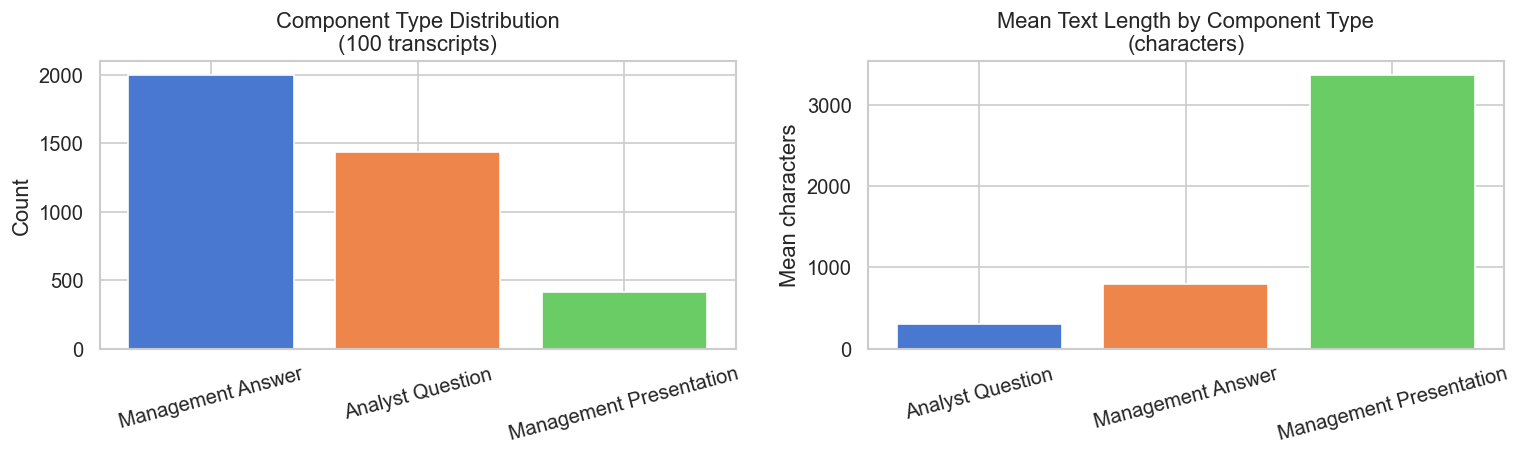


Summary statistics for text length by component type:


,count,mean,std,min,25%,50%,75%,max
component_label,,,,,,,,
Analyst Question,1434.0000,305.7441,217.5532,3.0000,131.0000,272.5000,437.0000,1170.0000
Management Answer,2002.0000,789.6578,828.0654,3.0000,154.0000,589.5000,1127.5000,7522.0000
Management Presentation,412.0000,3368.0388,4412.4487,4.0000,560.7500,1432.0000,4705.2500,28263.0000


In [11]:
# Component type distribution and text length analysis
# componenttypeid: 2=Presentation, 3=Analyst Q, 4=Management Answer

COMPONENT_LABELS = {2: 'Management Presentation', 3: 'Analyst Question', 4: 'Management Answer'}
sample_components['component_label'] = sample_components['componenttypeid'].map(COMPONENT_LABELS)
sample_components['text_length'] = sample_components['componenttext'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: count of each component type
cts = sample_components['component_label'].value_counts()
axes[0].bar(cts.index, cts.values, color=sns.color_palette('muted'))
axes[0].set_title('Component Type Distribution\n(100 transcripts)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)

# Right: average text length by component type
avg_len = sample_components.groupby('component_label')['text_length'].mean()
axes[1].bar(avg_len.index, avg_len.values, color=sns.color_palette('muted'))
axes[1].set_title('Mean Text Length by Component Type\n(characters)')
axes[1].set_ylabel('Mean characters')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print("\nSummary statistics for text length by component type:")
display(sample_components.groupby('component_label')['text_length'].describe())

In [12]:
# Read one full transcript end-to-end to get a feel for the structure.
# Pick the first transcript from the sample.

example_tid = sample_meta['transcriptid'].iloc[0]
example_company = sample_meta.loc[sample_meta['transcriptid'] == example_tid, 'companyname'].iloc[0]
example_date    = sample_meta.loc[sample_meta['transcriptid'] == example_tid, 'call_date'].iloc[0]

print(f"Transcript ID : {example_tid}")
print(f"Company       : {example_company}")
print(f"Date          : {example_date}")
print("=" * 70)

one_transcript = sample_components[sample_components['transcriptid'] == example_tid]\
    .sort_values('componentorder')

for _, row in one_transcript.iterrows():
    label = COMPONENT_LABELS.get(row['componenttypeid'], 'Unknown')
    if 'transcriptpersonname' in one_transcript.columns:
        speaker = row['transcriptpersonname'] or f"person#{row.get('transcriptpersonid')}"
    else:
        speaker = f"person#{row.get('transcriptpersonid')}"
    text = (row['componenttext'] or '')[:500]
    print(f"\n[{label}] {speaker}")
    print("-" * 60)
    print(text)
    if len(row['componenttext'] or '') > 500:
        print("... [truncated]")

Transcript ID : 1886877.0
Company       : Signature Bank
Date          : 2020-01-01

[Management Presentation] Ryan Nash
------------------------------------------------------------
All right. Up next, we're pleased to have Signature Bank. I cannot think of another bank that has repositioned itself more over the last 12 to 15 months, through the hiring of 3 strategic teams, capital call lending, venture banking and the specialized mortgage servicing banking team. This along with its 100 legacy teams should allow Signature to continue to have best-of-breed growth over the next few years. 
Here to tell us more about the strategy is President and CEO, Joe DePaolo; and EVP of C
... [truncated]

[Management Presentation] Joseph Depaolo
------------------------------------------------------------
Good afternoon, and thank you for being here and having an interest. What I wanted to do is something that we've always done, is give a little bit of an overview. But in addition to that, because of

### Full transcript pull — chunked download

In production we slice the CIQ pull by quarter (~12 months × 4 quarters per year) so a single failed network call only loses one chunk's work, not the whole multi-hour download. Each quarterly chunk is written to `data/raw/ciq_chunks/ciq_YYYY_QN.parquet` and the merge step (later, in Section 9) stitches them into one `data/raw/ciq_transcripts.parquet` file using the low-memory writer logic from `DataRetrieval/merge_chunks.py`.

The cell below defines the helper used by Section 9. Run Section 9 (not this cell) to actually trigger the download.

In [13]:
# ── Helpers used by the production pull (Section 9) ──────────────────────────
# Schema and SELECT clause match the existing 32 GB file at
#   LLM Project/Data/ciq_transcripts.parquet
# (12 columns, see _empty_transcripts_df below).

from sqlalchemy.exc import ProgrammingError


# These are the 12 columns of the existing CIQ parquet, in order.
CIQ_COLUMNS = [
    'companyid', 'companyname', 'transcriptid',
    'keydevid', 'event_date', 'event_type', 'call_date',
    'transcriptcomponentid', 'componenttypeid', 'transcriptpersonid',
    'componentorder', 'componenttext',
]


def _empty_transcripts_df():
    """Empty frame matching the existing ciq_transcripts.parquet schema (12 cols)."""
    return pd.DataFrame({
        'companyid':              pd.Series(dtype='float64'),     # actual file: double
        'companyname':            pd.Series(dtype='string'),
        'transcriptid':           pd.Series(dtype='float64'),     # actual file: double
        'keydevid':               pd.Series(dtype='float64'),
        'event_date':             pd.Series(dtype='string'),      # stored as string
        'event_type':             pd.Series(dtype='string'),
        'call_date':              pd.Series(dtype='string'),      # stored as string
        'transcriptcomponentid':  pd.Series(dtype='Int64'),
        'componenttypeid':        pd.Series(dtype='Int64'),
        'transcriptpersonid':     pd.Series(dtype='Int64'),
        'componentorder':         pd.Series(dtype='Int64'),
        'componenttext':          pd.Series(dtype='string'),
    })


def fetch_ciq_chunk(db, year: int, quarter: int) -> pd.DataFrame:
    """Pull one calendar-quarter slice of CIQ Transcripts joined with components.

    Produces the same 12 columns as the existing ciq_transcripts.parquet on disk
    (see CIQ_COLUMNS).  Joins:
      ciq_transcripts.ciqtranscript            (tc)   — event metadata
      ciq_transcripts.ciqtranscriptcomponent   (tcc)  — speaking segments
      ciq_transcripts.wrds_keydev              (kd)   — keydev event_date / event_type
        (left-joined; if your account lacks wrds_keydev, both fields will be NULL
         and you can drop the join — downstream notebooks reconstruct fiscal
         quarter / year from call_date.)
    """
    q_bounds = {1: ('01-01', '03-31'), 2: ('04-01', '06-30'),
                3: ('07-01', '09-30'), 4: ('10-01', '12-31')}
    start = f"{year}-{q_bounds[quarter][0]}"
    end   = f"{year}-{q_bounds[quarter][1]}"

    # NOTE: schema differences vs. older WRDS / the original PDF spec:
    #   * ciq_transcripts.wrds_keydev does not exist  → use the WRDS-built
    #     view ciq_transcripts.wrds_transcript_detail (companyid, companyname,
    #     keydeveventtypename, mostimportantdateutc, etc.) instead.
    #   * ciqtranscriptcomponent.componenttypeid was renamed to
    #     transcriptcomponenttypeid; we re-alias it back so the existing
    #     parquet schema and downstream code keep working unchanged.
    sql = f"""
        SELECT
            tc.companyid,
            tc.companyname,
            tc.transcriptid,
            tc.keydevid,
            tc.mostimportantdateutc::text       AS event_date,
            tc.keydeveventtypename              AS event_type,
            tc.transcriptcreationdate_utc::text AS call_date,
            tcc.transcriptcomponentid,
            tcc.transcriptcomponenttypeid       AS componenttypeid,
            tcc.transcriptpersonid,
            tcc.componentorder,
            tcc.componenttext
        FROM ciq_transcripts.wrds_transcript_detail AS tc
        INNER JOIN ciq_transcripts.ciqtranscriptcomponent AS tcc
            ON tc.transcriptid = tcc.transcriptid
        WHERE tcc.transcriptcomponenttypeid IN (2, 3, 4)
          AND tc.transcriptcreationdate_utc BETWEEN '{start}' AND '{end}'
    """
    return db.raw_sql(sql)


def merge_ciq_chunks(chunk_dir: Path, final_path: Path) -> int:
    """Stream all `ciq_*.parquet` chunks into one parquet file (low-memory).

    Same logic as DataRetrieval/merge_chunks.py — uses a streaming PyArrow
    ParquetWriter so we never load every chunk into memory at once.
    """
    import pyarrow.parquet as pq

    chunk_files = sorted(chunk_dir.glob('ciq_*.parquet'))
    if not chunk_files:
        raise FileNotFoundError(f"No ciq_*.parquet files found in {chunk_dir}")

    writer = None
    total_rows = 0
    for i, f in enumerate(chunk_files, 1):
        table = pq.read_table(f)
        total_rows += table.num_rows
        print(f"  [{i:>2}/{len(chunk_files)}] {f.name}: {table.num_rows:>10,} rows  "
              f"(cumulative: {total_rows:>12,})")
        if writer is None:
            writer = pq.ParquetWriter(final_path, table.schema, compression='snappy')
        writer.write_table(table)
        del table

    if writer is not None:
        writer.close()
    return total_rows


print("Helpers defined:")
print(f"  CIQ_COLUMNS  ({len(CIQ_COLUMNS)} cols): {CIQ_COLUMNS}")
print("  fetch_ciq_chunk(db, year, quarter)        -> DataFrame")
print("  merge_ciq_chunks(chunk_dir, final_path)   -> int (rows merged)")
print("  _empty_transcripts_df()                   -> empty DataFrame with the production schema")

Helpers defined:
  CIQ_COLUMNS  (12 cols): ['companyid', 'companyname', 'transcriptid', 'keydevid', 'event_date', 'event_type', 'call_date', 'transcriptcomponentid', 'componenttypeid', 'transcriptpersonid', 'componentorder', 'componenttext']
  fetch_ciq_chunk(db, year, quarter)        -> DataFrame
  merge_ciq_chunks(chunk_dir, final_path)   -> int (rows merged)
  _empty_transcripts_df()                   -> empty DataFrame with the production schema


---
## Section 3 — CRSP Monthly Returns

The **Center for Research in Security Prices (CRSP)** monthly stock file (`crsp.msf`) is the gold standard for stock return data in academic finance. The 8 columns we keep — same as the existing `LLM Project/Data/crsp_monthly_2010_2024.parquet`:

| Column | Meaning |
|--------|--------|
| `permno`     | CRSP permanent number — unique firm identifier (survives mergers/delisting) |
| `date`       | Month-end date (timestamp) |
| `ret`        | Monthly total return (includes dividends, capital gains) |
| `retx`       | Return excluding dividends |
| `shrout`     | Shares outstanding (thousands) |
| `prc`        | Closing price (negative = bid-ask midpoint when no closing price was available) |
| `vol`        | Trading volume |
| `market_cap` | `abs(prc) * shrout` — pre-computed in pandas after the pull |

**Universe filter:** the production query pulls *every* `crsp.msf` row in the date range — we deliberately do **not** filter on `exchcd`/`shrcd` at extraction time. Universe restriction (e.g. ordinary common shares on NYSE/AMEX/NASDAQ) is applied later, downstream of the panel merge, so the same raw file can serve multiple universe definitions without re-pulling.

In [14]:
# ⚠️ WRDS REQUIRED ─────────────────────────────────────────────────────────────
# Sample query — same column list and (no) filters as DataRetrieval/data_retrieval.py.
# We sample one year (2020) and a 5,000-row LIMIT just to inspect the schema.

sample_ret = db.raw_sql("""
    SELECT permno, date, ret, retx, shrout, prc, vol
    FROM crsp.msf
    WHERE date BETWEEN '2020-01-01' AND '2020-12-31'
    LIMIT 5000
""", date_cols=['date'])

print(f"Shape: {sample_ret.shape}")
print(f"\nData types:")
print(sample_ret.dtypes)
print(f"\nFirst 5 rows:")
display(sample_ret.head())

Shape: (5000, 7)

Data types:
permno             Int64
date      datetime64[ns]
ret              Float64
retx             Float64
shrout           Float64
prc              Float64
vol              Float64
dtype: object

First 5 rows:


,permno,date,ret,retx,shrout,prc,vol
0,10026,2020-01-31,-0.1000,-0.1000,18919.0000,165.8400,22433.0000
1,10028,2020-01-31,0.6074,0.6074,26924.0000,2.1700,27373.0000
2,10032,2020-01-31,-0.0756,-0.0756,29222.0000,71.1200,41351.0000
3,10044,2020-01-31,-0.0986,-0.0986,6000.0000,8.3200,4414.0000
4,10051,2020-01-31,-0.1152,-0.1152,37338.0000,24.4300,51275.0000


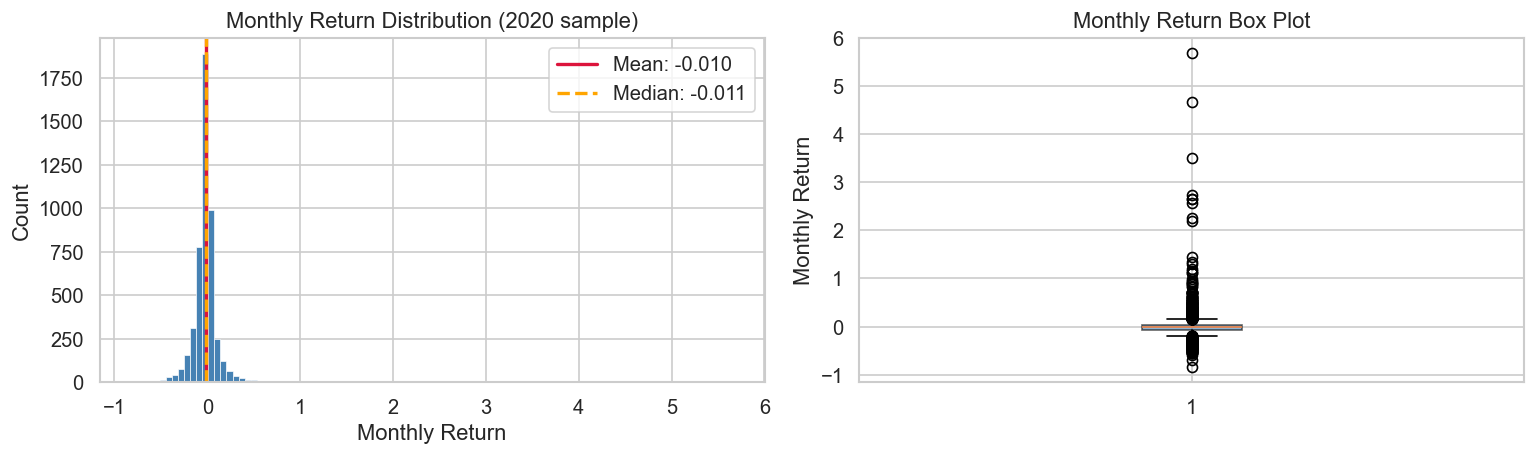


Return summary statistics:
count   4876.0000
mean      -0.0103
std        0.2007
min       -0.8351
25%       -0.0674
50%       -0.0112
75%        0.0222
max        5.6773
Name: ret, dtype: Float64


In [15]:
# Distribution of monthly returns
# Note: CRSP codes missing returns as NaN; -99 (old files) may appear and should be cleaned.

ret_clean = sample_ret['ret'].dropna()
ret_clean = ret_clean[ret_clean > -0.99]  # remove obvious data errors / delistings

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram — note the fat left tail (COVID crash in 2020)
axes[0].hist(ret_clean, bins=100, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].axvline(ret_clean.mean(), color='crimson', lw=2, label=f'Mean: {ret_clean.mean():.3f}')
axes[0].axvline(ret_clean.median(), color='orange', lw=2, linestyle='--', label=f'Median: {ret_clean.median():.3f}')
axes[0].set_title('Monthly Return Distribution (2020 sample)')
axes[0].set_xlabel('Monthly Return')
axes[0].set_ylabel('Count')
axes[0].legend()

# Box plot
axes[1].boxplot(ret_clean, vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Monthly Return Box Plot')
axes[1].set_ylabel('Monthly Return')

plt.tight_layout()
plt.show()

print("\nReturn summary statistics:")
print(ret_clean.describe())

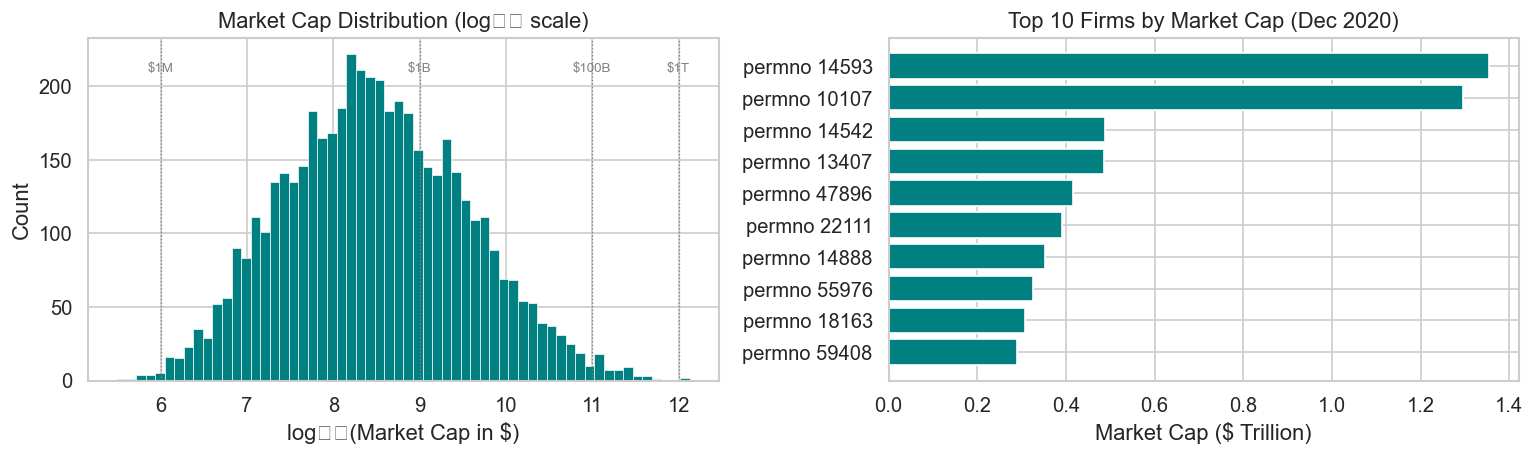


Median market cap: $0.28B
Mean market cap:   $5.53B


In [16]:
# Compute market cap = |price| * shrout
# - abs(prc) because CRSP uses negative prices for bid-ask midpoints.
# - shrout is in thousands; we keep it that way (so mktcap is in $thousands)
#   to stay consistent with DataRetrieval/data_retrieval.py.
# Convert to actual dollars only at display time below.

sample_ret['mktcap'] = sample_ret['prc'].abs() * sample_ret['shrout']  # thousands of $
sample_ret['market_cap'] = sample_ret['mktcap'] * 1000                   # dollars (for plot)

# Log market cap for readability (order-of-magnitude differences)
mc_valid = sample_ret['market_cap'].dropna()
mc_valid = mc_valid[mc_valid > 0]
mc_log = np.log10(mc_valid)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(mc_log, bins=60, color='teal', edgecolor='white', linewidth=0.4)
axes[0].set_title('Market Cap Distribution (log₁₀ scale)')
axes[0].set_xlabel('log₁₀(Market Cap in $)')
axes[0].set_ylabel('Count')
# Add labels for scale reference
for val, label in [(6, '$1M'), (9, '$1B'), (11, '$100B'), (12, '$1T')]:
    axes[0].axvline(val, color='gray', lw=0.8, linestyle=':')
    axes[0].text(val, axes[0].get_ylim()[1]*0.9, label, ha='center', fontsize=8, color='gray')

# Top 10 by market cap
top10 = sample_ret.groupby('permno')['market_cap'].last().nlargest(10)
axes[1].barh(range(len(top10)), top10.values / 1e12, color='teal')
axes[1].set_yticks(range(len(top10)))
axes[1].set_yticklabels([f'permno {p}' for p in top10.index])
axes[1].set_xlabel('Market Cap ($ Trillion)')
axes[1].set_title('Top 10 Firms by Market Cap (Dec 2020)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"\nMedian market cap: ${mc_valid.median()/1e9:.2f}B")
print(f"Mean market cap:   ${mc_valid.mean()/1e9:.2f}B")

### Section 3b — CRSP Daily Returns

The production pull also grabs daily returns (`crsp.dsf`) so downstream notebooks can compute event-study CARs around earnings-call dates. Daily is much larger than monthly (≈250× more rows per firm-year), so we set `skip_daily=True` in tests when only the monthly file is needed.

| Column | Meaning |
|--------|--------|
| `permno` | CRSP permanent number |
| `date`   | Trading day |
| `ret`    | Daily total return |
| `prc`    | Closing price |
| `vol`    | Trading volume |

In [17]:
# ⚠️ WRDS REQUIRED ─────────────────────────────────────────────────────────────
# Sample of CRSP Daily Returns — same column list as data_retrieval.py.
# We pull only one month (Mar 2020 — COVID crash) and a 5,000-row LIMIT here.

sample_dsf = db.raw_sql("""
    SELECT permno, date, ret, prc, vol
    FROM crsp.dsf
    WHERE date BETWEEN '2020-03-01' AND '2020-03-31'
    LIMIT 5000
""", date_cols=['date'])

print(f"Shape: {sample_dsf.shape}")
print(f"Date range: {sample_dsf['date'].min().date()} → {sample_dsf['date'].max().date()}")
print(f"Distinct permnos: {sample_dsf['permno'].nunique():,}")
display(sample_dsf.head())

# Quick sanity: cross-sectional mean daily return during the COVID crash week
crash_week = sample_dsf[(sample_dsf['date'] >= '2020-03-09') & (sample_dsf['date'] <= '2020-03-13')]
if len(crash_week):
    print(f"\nMean cross-sectional daily return Mar 9–13, 2020: "
          f"{crash_week['ret'].mean():+.2%}  (n={len(crash_week):,} firm-days)")

Shape: (5000, 5)
Date range: 2020-03-02 → 2020-03-02
Distinct permnos: 5,000


,permno,date,ret,prc,vol
0,10026,2020-03-02,0.0196,163.9700,128181.0000
1,10028,2020-03-02,0.1429,3.0400,752535.0000
2,10032,2020-03-02,0.0056,66.7200,164271.0000
3,10044,2020-03-02,0.0183,7.8000,10635.0000
4,10051,2020-03-02,0.0048,23.1800,312404.0000


---
## Section 4 — Compustat Quarterly Fundamentals

**Compustat** (also from S&P Global) is the standard source for firm accounting data. We use the quarterly file (`comp.fundq`). The columns we keep — same as `DataRetrieval/data_retrieval.py`:

| Field | Meaning | Used for |
|-------|---------|-----|
| `gvkey` | Compustat permanent key | firm identifier in this DB |
| `datadate` | Fiscal quarter end date | timing of financial statements |
| `fyearq` / `fqtr` | Fiscal year / quarter | time index |
| `ceqq`   | Common equity (book value) | B/M ratio |
| `epspxq` | EPS, diluted, excluding extraordinary items | earnings surprise |
| `atq`    | Total assets | size control |
| `saleq`  | Sales | growth control |
| `ibq`    | Income before extraordinary items | accruals / profitability |
| `cshoq`  | Common shares outstanding | market value |
| `prccq`  | Price close, quarter-end | market value |

**Standard academic filter** (applied at extraction time so downstream code never has to think about it):

```sql
indfmt   = 'INDL'   -- Industrial format (excludes financials' bank-style format)
datafmt  = 'STD'    -- Standardised data
popsrc   = 'D'      -- Domestic source
consol   = 'C'      -- Consolidated
```

We do **not** add `fic = 'USA'` here: the IBES side already restricts to US-listed firms via `statsumu_epsus`, and forcing `fic='USA'` on Compustat drops some legitimately-listed dual-headquartered firms (Schlumberger, etc.).

In [18]:
# ⚠️ WRDS REQUIRED ─────────────────────────────────────────────────────────────
# Sample query — same column list and standard academic filter as
# DataRetrieval/data_retrieval.py.

sample_fund = db.raw_sql("""
    SELECT gvkey, datadate, fyearq, fqtr,
           ceqq, epspxq, atq, saleq, ibq, cshoq, prccq
    FROM comp.fundq
    WHERE datadate BETWEEN '2019-01-01' AND '2020-12-31'
      AND indfmt  = 'INDL'
      AND datafmt = 'STD'
      AND popsrc  = 'D'
      AND consol  = 'C'
    LIMIT 5000
""", date_cols=['datadate'])

print(f"Shape: {sample_fund.shape}")
print(f"Distinct gvkeys: {sample_fund['gvkey'].nunique():,}")
print(f"Quarter coverage: {sample_fund[['fyearq','fqtr']].drop_duplicates().shape[0]} unique fy-q")
display(sample_fund.head())

Shape: (5000, 11)
Distinct gvkeys: 5,000
Quarter coverage: 5 unique fy-q


,gvkey,datadate,fyearq,fqtr,ceqq,epspxq,atq,saleq,ibq,cshoq,prccq
0,001410,2019-01-31,2019,1,1461.1000,0.2000,3686.4000,1607.9000,13.0000,66.2100,34.1900
1,001562,2019-01-31,2018,3,114.3560,0.0700,160.8210,27.0030,2.3010,31.0670,11.0600
2,001618,2019-01-31,2018,3,87.9710,-0.1800,104.5100,2.3810,-1.4540,8.1280,6.2200
3,001632,2019-01-31,2019,1,11585.4370,0.9600,21828.2780,1541.1010,355.0060,368.3140,98.8600
4,001704,2019-01-31,2019,1,8209.0000,0.8100,18922.0000,3753.0000,771.0000,949.3930,39.0800


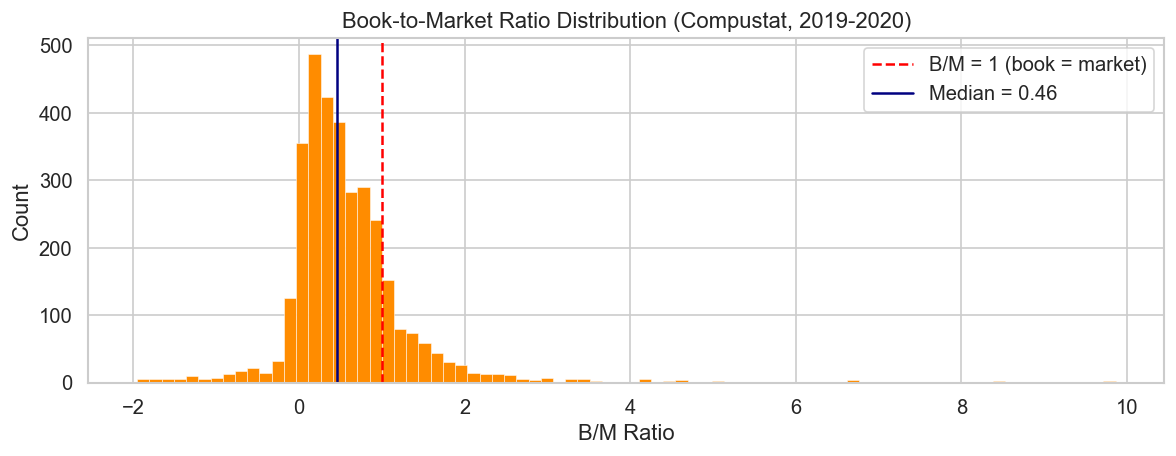


B/M ratio summary (trimmed sample):
count   3304.0000
mean       0.5983
std        0.8449
min       -1.9524
25%        0.1730
50%        0.4554
75%        0.8471
max        9.8601
Name: bm_ratio, dtype: Float64

% firms with B/M < 0 (negative book equity): 11.5%


In [19]:
# Compute Book-to-Market (B/M) ratio
# B/M = Book Equity / Market Equity
#      = ceqq / (prccq * cshoq)
# Low B/M = 'growth' stocks; High B/M = 'value' stocks

sample_fund['market_equity'] = sample_fund['prccq'].abs() * sample_fund['cshoq']
sample_fund['bm_ratio'] = sample_fund['ceqq'] / sample_fund['market_equity']

# Remove extreme outliers for plotting (|B/M| < 10)
bm = sample_fund['bm_ratio'].dropna()
bm_trimmed = bm[(bm > -2) & (bm < 10)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(bm_trimmed, bins=80, color='darkorange', edgecolor='white', linewidth=0.3)
ax.axvline(1.0, color='red', lw=1.5, linestyle='--', label='B/M = 1 (book = market)')
ax.axvline(bm_trimmed.median(), color='navy', lw=1.5, label=f'Median = {bm_trimmed.median():.2f}')
ax.set_title('Book-to-Market Ratio Distribution (Compustat, 2019-2020)')
ax.set_xlabel('B/M Ratio')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nB/M ratio summary (trimmed sample):")
print(bm_trimmed.describe())
print(f"\n% firms with B/M < 0 (negative book equity): {(bm < 0).mean():.1%}")

---
## Section 5 — IBES Analyst Forecasts & SUE

**Institutional Brokers' Estimate System (IBES)** collects analyst earnings forecasts for publicly traded companies. We use the **unadjusted** summary file `ibes.statsumu_epsus` (note the `u` for *unadjusted* — this is the file that does **not** retroactively split-adjust historical forecasts, which is the version most papers use because it preserves the analyst's actual published EPS).

The 7 columns we keep — same as the existing `LLM Project/Data/ibes_statsum_2010_2023.parquet`:

| Column | Meaning |
|--------|--------|
| `ticker`   | IBES ticker (firm identifier in IBES) |
| `fpedats`  | Fiscal-period-end date — quarter the forecast targets |
| `statpers` | Statistics-period date — vintage of the consensus snapshot |
| `meanest`  | Mean (consensus) EPS forecast |
| `stdev`    | Cross-analyst std dev of forecasts |
| `numest`   | Number of analysts contributing |
| `actual`   | Actual reported EPS |

**Filter `fpi = '6'`**: keep only quarterly EPS forecasts (`'1'` is annual).

> The production parquet does **not** carry `cusip` (used for IBES↔CRSP linking) or `anndats_act` (the announcement date of the actual). If you need either, re-pull from WRDS adding the column to the SELECT — the existing downstream notebooks don't reference them.

### Standardized Unexpected Earnings (SUE)

The canonical surprise measure for event studies is

$$\text{SUE}_{i,t} = \frac{\text{actual}_{i,t} - \text{mean\_forecast}_{i,t}}{\text{std\_forecast}_{i,t}},$$

where the mean and std are measured in the period just *before* the announcement (we will pick the latest `statpers ≤ anndats_act` later).

**Edge cases to handle:**
- `stdev = 0` (all analysts identical): set SUE = NaN.
- `numest = 1` (single analyst): no valid std; use a price-scaled fallback.
- Large outliers (|SUE| > 10): typically data errors or extraordinary items — winsorize at 1%/99%.

In [20]:
# ⚠️ WRDS REQUIRED ─────────────────────────────────────────────────────────────
# Sample query — column list matches the existing
#   LLM Project/Data/ibes_statsum_2010_2023.parquet  schema (7 cols).
# Note: cusip and anndats_act are NOT stored in the production parquet, so
# we omit them here too.  If you need cusip for a CRSP merge, re-pull from
# WRDS and add it; if you need the announcement date for event studies,
# re-pull with anndats_act.

# NOTE: ibes.statsumu_epsus does NOT have an `actual` column on this WRDS
# subscription — it only has the analyst forecast distribution.  Realized
# EPS lives in ibes.actu_epsus.value (key = ticker + pends), so we LEFT JOIN.
# Keep the same downstream alias `actual` for compatibility.

sample_ibes = db.raw_sql("""
    SELECT s.ticker, s.fpedats, s.statpers,
           s.meanest, s.stdev, s.numest,
           a.value AS actual
    FROM ibes.statsumu_epsus AS s
    LEFT JOIN ibes.actu_epsus AS a
        ON s.ticker = a.ticker
       AND s.fpedats = a.pends
       AND a.pdicity = 'QTR'
    WHERE s.fpedats BETWEEN '2019-10-01' AND '2020-12-31'
      AND s.fpi = '6'
      AND a.value IS NOT NULL
    LIMIT 5000
""", date_cols=['statpers', 'fpedats'])

print(f"Shape: {sample_ibes.shape}")
print(f"Distinct tickers: {sample_ibes['ticker'].nunique():,}")
display(sample_ibes.head())

Shape: (5000, 7)
Distinct tickers: 340


,ticker,fpedats,statpers,meanest,stdev,numest,actual
0,000V,2019-12-31,2019-11-14,-0.4200,0.9300,6.0000,-0.6800
1,000V,2019-12-31,2019-12-19,-0.4300,0.9400,6.0000,-0.6800
2,000V,2019-12-31,2020-01-16,-0.4300,0.9400,6.0000,-0.6800
3,000V,2019-12-31,2020-02-20,-0.4300,0.9400,6.0000,-0.6800
4,000V,2020-03-31,2020-03-19,-0.8100,0.1700,5.0000,-0.6200


% rows with stdev = 0:    3.5%
% rows with stdev = NaN:  9.8%
% rows with valid SUE:    87.0%

SUE distribution (winsorized):
count   4349.0000
mean       0.4893
std        5.2386
min      -26.0750
25%       -0.8889
50%        0.5000
75%        2.1304
max       16.0000
Name: sue_wins, dtype: float64


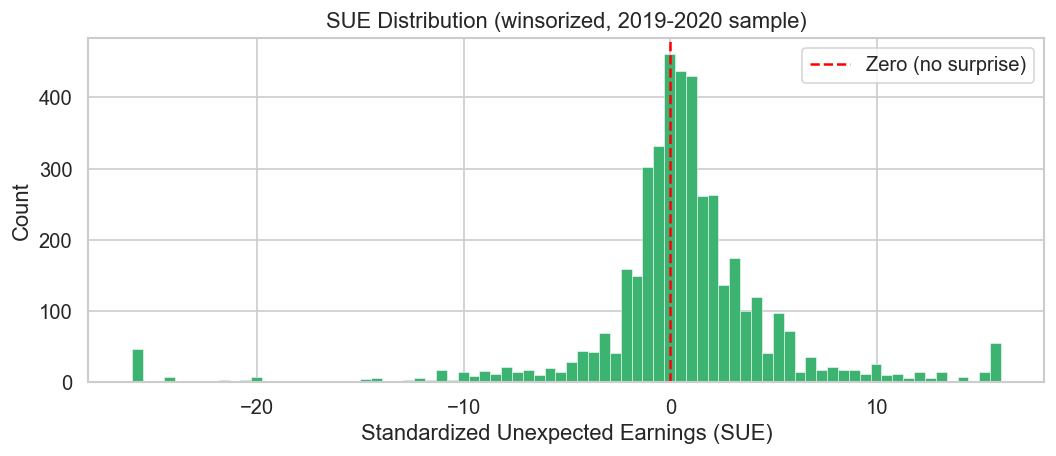

In [21]:
# Compute SUE — three versions:
#   sue_std  : standard version using std deviation in denominator
#   sue_raw  : raw forecast error (no scaling)
#   sue_wins : winsorized at 1st and 99th percentile

df_ibes = sample_ibes.copy()
df_ibes['forecast_error'] = df_ibes['actual'] - df_ibes['meanest']

# Standard SUE: divide by std. When std == 0 or NaN, result is NaN.
df_ibes['sue_std'] = np.where(
    (df_ibes['stdev'] > 0) & df_ibes['stdev'].notna(),
    df_ibes['forecast_error'] / df_ibes['stdev'],
    np.nan
)

# Winsorized version at 1% / 99%
p01 = df_ibes['sue_std'].quantile(0.01)
p99 = df_ibes['sue_std'].quantile(0.99)
df_ibes['sue_wins'] = df_ibes['sue_std'].clip(lower=p01, upper=p99)

print(f"% rows with stdev = 0:    {(df_ibes['stdev'] == 0).mean():.1%}")
print(f"% rows with stdev = NaN:  {df_ibes['stdev'].isna().mean():.1%}")
print(f"% rows with valid SUE:    {df_ibes['sue_std'].notna().mean():.1%}")
print(f"\nSUE distribution (winsorized):")
print(df_ibes['sue_wins'].describe())

# Plot SUE distribution
sue_valid = df_ibes['sue_wins'].dropna()
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(sue_valid, bins=80, color='mediumseagreen', edgecolor='white', linewidth=0.3)
ax.axvline(0, color='red', lw=1.5, linestyle='--', label='Zero (no surprise)')
ax.set_title('SUE Distribution (winsorized, 2019-2020 sample)')
ax.set_xlabel('Standardized Unexpected Earnings (SUE)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

---
## Section 6 — Fama-French Factors

The Fama-French five-factor model (FF5) extends the classic three-factor model with two additional factors:

| Factor | Name | Intuition |
|--------|------|-----------|
| `mktrf` | Market excess return | Compensation for bearing systematic risk |
| `smb` | Small Minus Big | Size premium |
| `hml` | High Minus Low | Value premium |
| `rmw` | Robust Minus Weak | Profitability premium |
| `cma` | Conservative Minus Aggressive | Investment premium |
| `umd` | Up Minus Down | Momentum factor (from Carhart) |
| `rf` | Risk-free rate | One-month T-bill rate |

In [39]:
# ⚠️ WRDS REQUIRED (unless parquet already on disk) ────────────────────────────
# Fama-French factors live in the `ff` library on WRDS.
# ff.factors_monthly = 3-factor model (+ UMD); ff.fivefactors_monthly = 5-factor.
#
# If you see: OperationalError … "could not receive data from server" /
# "SSL SYSCALL error: Operation timed out" — that is a **network drop** between
# your laptop and WRDS (Wi‑Fi/VPN/firewall), not a SQL mistake. Retry this
# cell on a stable connection, or run from campus / VPN.

_ff_from_disk = False
if FF_FACTORS_PARQUET.exists():
    sample_ff = pd.read_parquet(FF_FACTORS_PARQUET)
    _ff_from_disk = True
    print(f"⊙ Loaded Fama-French factors from disk (skip WRDS): {FF_FACTORS_PARQUET.name}")
else:
    sample_ff = db.raw_sql("""
        SELECT f.date, f.mktrf, f.smb, f.hml, f.rmw, f.cma, f.rf,
               m.umd
        FROM ff.fivefactors_monthly f
        LEFT JOIN ff.factors_monthly m ON f.date = m.date
        WHERE f.date BETWEEN '2006-01-01' AND '2024-12-31'
        ORDER BY f.date
    """, date_cols=['date'])

print(f"Shape: {sample_ff.shape}")
print(f"Date range: {sample_ff['date'].min()} to {sample_ff['date'].max()}")
display(sample_ff.head())

# Save full Fama–French panel under <PROJECT_ROOT>/Data/
# (on this machine that resolves to:
#  /Users/tiantian/Downloads/CU Material/S3/5293/Project/LLM Project/Data/)
RAW_DIR.mkdir(parents=True, exist_ok=True)
if not _ff_from_disk:
    sample_ff.to_parquet(FF_FACTORS_PARQUET, index=False)
    print(f"Saved Fama-French factors → {FF_FACTORS_PARQUET.resolve()}")
else:
    print(f"(Parquet unchanged on disk: {FF_FACTORS_PARQUET.resolve()})")

Shape: (228, 8)
Date range: 2006-01-01 00:00:00 to 2024-12-01 00:00:00


,date,mktrf,smb,hml,rmw,cma,rf,umd
0,2006-01-01,0.0303,0.0583,0.0099,-0.0066,-0.0035,0.0035,0.0252
1,2006-02-01,-0.0030,-0.0046,-0.0031,-0.0054,0.0198,0.0034,-0.0178
2,2006-03-01,0.0147,0.0334,0.0061,0.0003,-0.0044,0.0037,0.0126
3,2006-04-01,0.0073,-0.0079,0.0226,0.0174,-0.0013,0.0036,0.0060
4,2006-05-01,-0.0356,-0.0290,0.0238,0.0087,0.0153,0.0043,-0.0366


Saved Fama-French factors → /Users/tiantian/Downloads/CU Material/S3/5293/Project/LLM Project/Data/fama_french_monthly_2006_2024.parquet


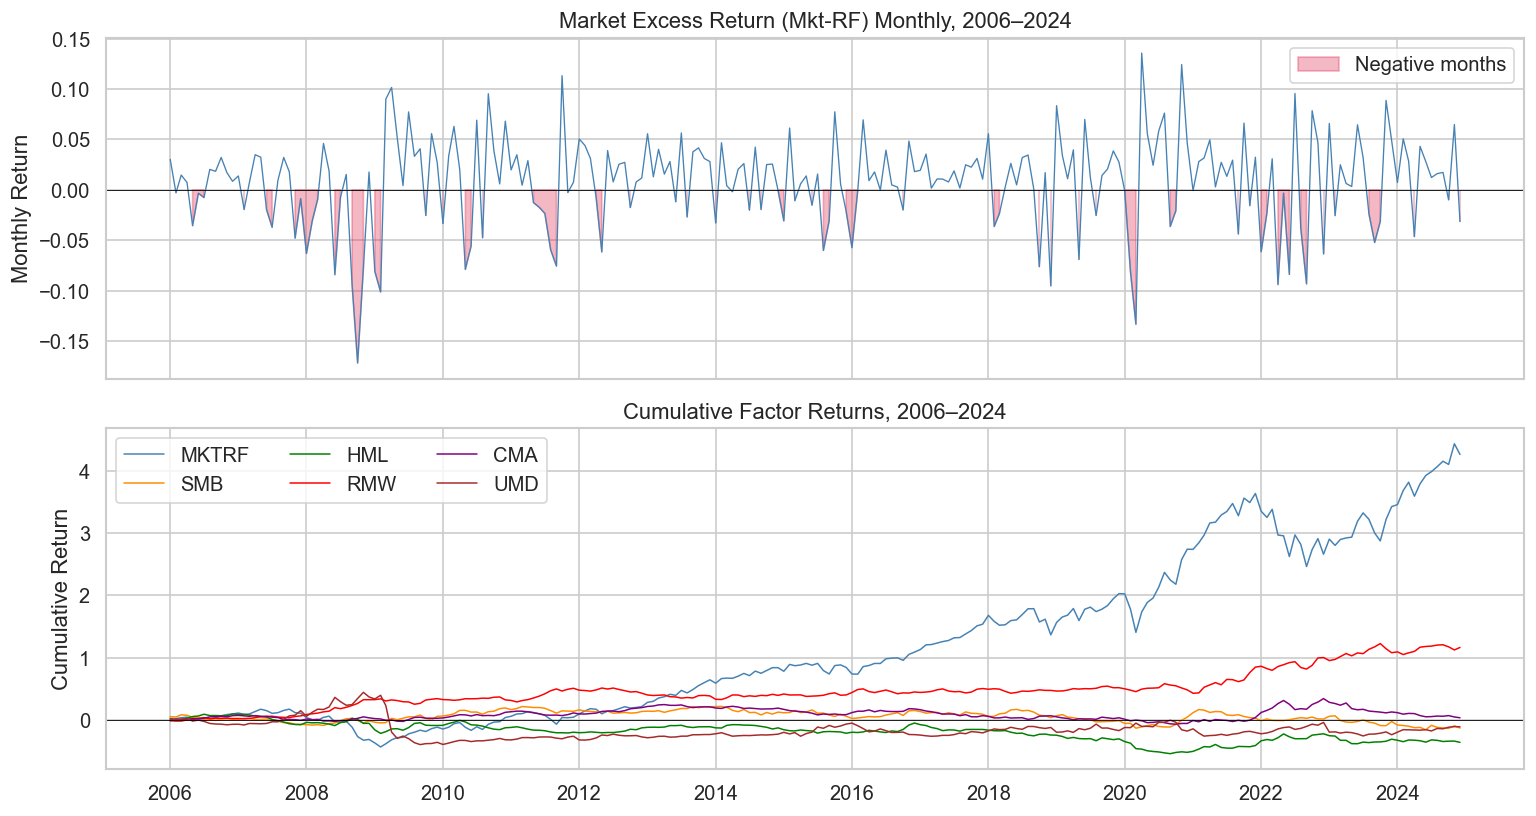


Factor correlation matrix:


,mktrf,smb,hml,rmw,cma,umd
mktrf,1.0000,0.3620,0.1560,-0.1890,-0.1380,-0.3780
smb,0.3620,1.0000,0.3340,-0.3770,0.0460,-0.3110
hml,0.1560,0.3340,1.0000,-0.0010,0.6000,-0.3420
rmw,-0.1890,-0.3770,-0.0010,1.0000,0.1020,0.0890
cma,-0.1380,0.0460,0.6000,0.1020,1.0000,-0.0020
umd,-0.3780,-0.3110,-0.3420,0.0890,-0.0020,1.0000


In [23]:
# Time series of market excess return — reveals crisis periods clearly
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

# Top: level series
axes[0].plot(sample_ff['date'], sample_ff['mktrf'], color='steelblue', lw=0.8)
axes[0].axhline(0, color='black', lw=0.5)
axes[0].fill_between(sample_ff['date'], sample_ff['mktrf'], 0,
                     where=sample_ff['mktrf'] < 0, color='crimson', alpha=0.3, label='Negative months')
axes[0].set_title('Market Excess Return (Mkt-RF) Monthly, 2006–2024')
axes[0].set_ylabel('Monthly Return')
axes[0].legend()

# Bottom: all five factors overlaid
for col, color in zip(['mktrf', 'smb', 'hml', 'rmw', 'cma', 'umd'],
                       ['steelblue', 'darkorange', 'green', 'red', 'purple', 'brown']):
    if col in sample_ff.columns:
        # Compute cumulative return for comparison
        cumret = (1 + sample_ff[col].fillna(0)).cumprod() - 1
        axes[1].plot(sample_ff['date'], cumret, lw=0.9, label=col.upper(), color=color)

axes[1].axhline(0, color='black', lw=0.5)
axes[1].set_title('Cumulative Factor Returns, 2006–2024')
axes[1].set_ylabel('Cumulative Return')
axes[1].legend(ncol=3)

plt.tight_layout()
plt.show()

# Factor correlation matrix
ff_cols = ['mktrf', 'smb', 'hml', 'rmw', 'cma', 'umd']
ff_cols = [c for c in ff_cols if c in sample_ff.columns]
print("\nFactor correlation matrix:")
display(sample_ff[ff_cols].corr().round(3))

---
## Section 7 — S&P 500 Universe Filter

We restrict the analysis to **S&P 500 constituent firms** for two reasons:
1. Earnings calls outside the S&P 500 are less consistently covered by Capital IQ.
2. The paper focuses on large-cap firms where analyst scrutiny is highest.

`crsp.msp500list` stores the historical composition of the index with `start` and `ending` dates for each firm's membership spell.

In [24]:
# ⚠️ WRDS REQUIRED ─────────────────────────────────────────────────────────────
sample_sp500 = db.raw_sql("""
    SELECT permno, start, ending
    FROM crsp.msp500list
    ORDER BY start
""", date_cols=['start', 'ending'])

print(f"Total membership spells: {len(sample_sp500):,}")
print(f"Unique permnos ever in S&P 500: {sample_sp500['permno'].nunique():,}")
display(sample_sp500.head(10))

Total membership spells: 2,064
Unique permnos ever in S&P 500: 1,936


,permno,start,ending
0,15325,1925-12-31,1944-06-07
1,10233,1925-12-31,1933-03-28
2,10137,1925-12-31,1976-06-30
3,14509,1925-12-31,1982-06-02
4,14496,1925-12-31,1983-12-28
5,14322,1925-12-31,2005-03-24
6,12706,1925-12-31,1981-06-24
7,12749,1925-12-31,1944-06-07
8,12810,1925-12-31,1941-08-20
9,11041,1925-12-31,1953-06-22


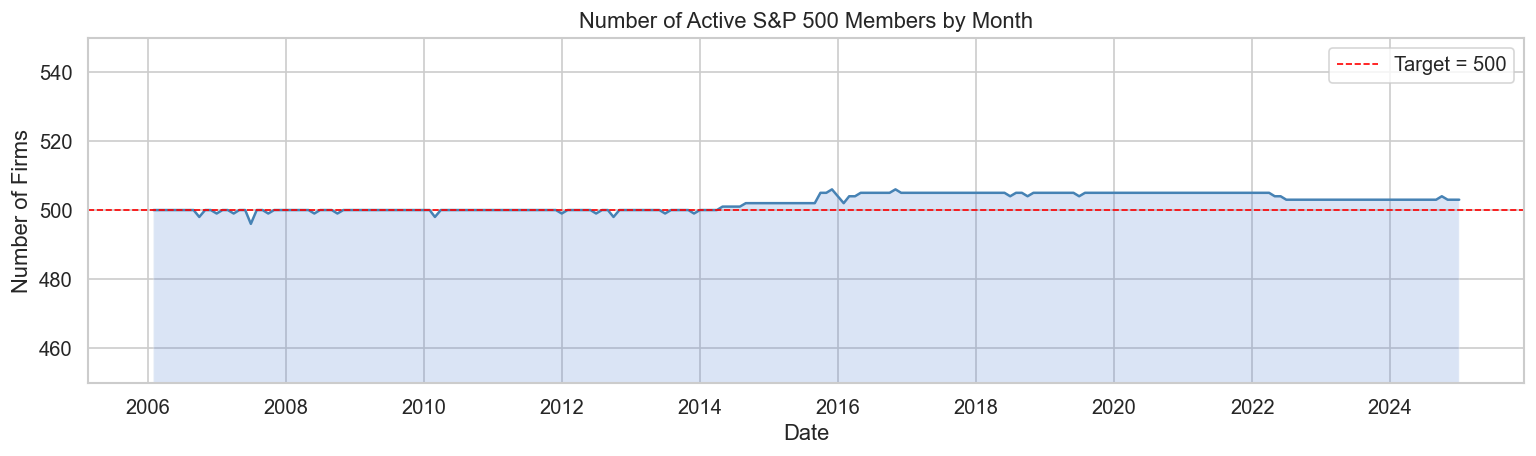


Mean members: 502.2
Min members:  496
Max members:  506


In [25]:
# Count active S&P 500 members at each month-end, 2006–2024
# Methodology: for a date d, a firm is active if start <= d <= ending (or ending is null)

dates = pd.date_range('2006-01-31', '2024-12-31', freq='ME')
sp500_counts = []

for d in dates:
    is_active = (
        (sample_sp500['start'] <= d) &
        ((sample_sp500['ending'].isna()) | (sample_sp500['ending'] >= d))
    )
    sp500_counts.append({'date': d, 'n_members': is_active.sum()})

sp500_ts = pd.DataFrame(sp500_counts)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(sp500_ts['date'], sp500_ts['n_members'], color='steelblue', lw=1.5)
ax.axhline(500, color='red', lw=1, linestyle='--', label='Target = 500')
ax.fill_between(sp500_ts['date'], sp500_ts['n_members'], alpha=0.2)
ax.set_title('Number of Active S&P 500 Members by Month')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Firms')
ax.legend()
ax.set_ylim(450, 550)
plt.tight_layout()
plt.show()

print(f"\nMean members: {sp500_ts['n_members'].mean():.1f}")
print(f"Min members:  {sp500_ts['n_members'].min()}")
print(f"Max members:  {sp500_ts['n_members'].max()}")

---
## Section 8 — Identifier Linking

### The Linking Problem

Each database vendor assigns its own firm identifier:

| Database | Identifier | Notes |
|----------|-----------|-------|
| CRSP | `permno` | Permanent, survives mergers/name changes |
| Compustat | `gvkey` | Permanent, global coverage |
| IBES | `ticker` | Can change; `cusip` is the standard bridge to CRSP but our parquet drops it (see Section 5) |
| Capital IQ | `companyid` | Proprietary |

The single linking parquet we materialise is `crsp_compustat_link.parquet`, sourced from:

- **`crsp.ccmxpf_lnkhist`** — maps `gvkey` ↔ CRSP `permno` (we drop `lpermco`) with date-valid ranges (`linkdt`, `linkenddt`). This is the historical link table; it includes superseded mappings, which is exactly what we want when joining historical accounting data.

For IBES↔CRSP the conventional bridge is 8-digit CUSIP via `ibes.statsumu_epsus.cusip` ↔ `crsp.msenames.ncusip`; if you re-add `cusip` to the IBES pull (Section 5) you can build that link the same way.

We restrict the CCM pull to high-quality / primary links — `linktype IN ('LC', 'LU')` and `linkprim IN ('P', 'C')`:
- `LC` = link confirmed by CRSP
- `LU` = unresearched (lower confidence, but standard practice to keep)
- `P` = primary issue
- `C` = primary issue, multiple links exist

These links are **date-sensitive**: a company may have different `gvkey`s before and after a major corporate event. Always apply the `linkdt <= date <= linkenddt` filter when merging.

In [26]:
# ⚠️ WRDS REQUIRED ─────────────────────────────────────────────────────────────
# Sample query — column list matches the existing
#   LLM Project/Data/crsp_compustat_link.parquet  schema (6 cols).
# permco is NOT stored in the production parquet (the gvkey↔permno mapping is
# enough for the merges we run downstream).  Add `lpermco AS permco` if you
# need it for a particular join.

sample_ccm = db.raw_sql("""
    SELECT gvkey, lpermno AS permno,
           linktype, linkprim, linkdt, linkenddt
    FROM crsp.ccmxpf_lnkhist
    WHERE linktype IN ('LC', 'LU')
      AND linkprim IN ('P', 'C')
    LIMIT 5000
""", date_cols=['linkdt', 'linkenddt'])

print(f"Shape: {sample_ccm.shape}")
print(f"\nLink type distribution:")
print(sample_ccm['linktype'].value_counts())
print(f"\nLink primary distribution:")
print(sample_ccm['linkprim'].value_counts())
print(f"\nDistinct gvkeys: {sample_ccm['gvkey'].nunique():,}  |  "
      f"Distinct permnos: {sample_ccm['permno'].nunique():,}")
display(sample_ccm.head())

Shape: (5000, 6)

Link type distribution:
linktype
LU    3397
LC    1603
Name: count, dtype: Int64

Link primary distribution:
linkprim
P    3108
C    1892
Name: count, dtype: Int64

Distinct gvkeys: 3,896  |  Distinct permnos: 4,072


,gvkey,permno,linktype,linkprim,linkdt,linkenddt
0,001000,25881.0000,LU,P,1970-11-13,1978-06-30
1,001001,10015.0000,LU,P,1983-09-20,1986-07-31
2,001002,10023.0000,LC,C,1972-12-14,1973-06-05
3,001003,10031.0000,LU,C,1983-12-07,1989-08-16
4,001004,54594.0000,LU,P,1972-04-24,NaT


In [27]:
# Demonstrate a date-filtered merge: add permno to Compustat rows
# Step 1: take the first 500 Compustat rows from our sample
# Step 2: cross-join with CCM and apply the date filter

if 'sample_fund' in dir() and 'sample_ccm' in dir():
    fund_sub = sample_fund[['gvkey', 'datadate']].head(500).copy()
    fund_sub['gvkey'] = fund_sub['gvkey'].astype(str)
    sample_ccm['gvkey'] = sample_ccm['gvkey'].astype(str)

    merged = fund_sub.merge(sample_ccm[['gvkey', 'permno', 'linktype', 'linkdt', 'linkenddt']],
                             on='gvkey', how='left')

    # Apply date-validity filter
    sentinel = pd.Timestamp('2099-12-31')
    merged['linkenddt_filled'] = merged['linkenddt'].fillna(sentinel)
    valid_link = (
        (merged['linkdt'].isna()) | (merged['datadate'] >= merged['linkdt'])
    ) & (
        merged['datadate'] <= merged['linkenddt_filled']
    )
    merged_valid = merged[valid_link].drop_duplicates(subset=['gvkey', 'datadate'])

    n_total    = len(fund_sub)
    n_linked   = merged_valid['permno'].notna().sum()
    pct_linked = n_linked / n_total * 100

    print(f"Compustat rows in sample:     {n_total}")
    print(f"Rows with valid permno link:  {n_linked}")
    print(f"Link success rate:            {pct_linked:.1f}%")
    display(merged_valid.head(5))
else:
    print("Run the Compustat and CCM cells above first.")

Compustat rows in sample:     500
Rows with valid permno link:  44
Link success rate:            8.8%


,gvkey,datadate,permno,linktype,linkdt,linkenddt,linkenddt_filled
0,001410,2019-01-31,47730.0000,LU,1969-02-13,NaT,2099-12-31
1,001562,2019-01-31,13777.0000,LU,1983-02-28,NaT,2099-12-31
2,001618,2019-01-31,38746.0000,LU,1966-01-31,NaT,2099-12-31
3,001632,2019-01-31,60871.0000,LC,1972-12-14,NaT,2099-12-31
4,001704,2019-01-31,14702.0000,LU,1972-12-14,NaT,2099-12-31


---
## Section 9 — Full Pipeline Execution

Now we run the production pull for the project scope (2010–2023, returns extended to 2024). The five cells below mirror `DataRetrieval/data_retrieval.py` step-by-step:

1. **CIQ Transcripts** (`ciq_transcripts.ciqtranscript` ⨝ `ciqtranscriptcomponent`) — chunked quarterly pull → merge to `data/raw/ciq_transcripts.parquet`. **30–60 min**.
2. **CRSP Monthly** (`crsp.msf`) → `data/raw/crsp_monthly.parquet`. **2–5 min**.
3. **CRSP Daily** (`crsp.dsf`) → `data/raw/crsp_daily.parquet`. **5–15 min**.
4. **CCM Link** (`crsp.ccmxpf_lnkhist`) → `data/raw/ccm_link.parquet`. **<1 min**.
5. **Compustat Quarterly** (`comp.fundq`) → `data/raw/compustat_fundq.parquet`. **2–5 min**.
6. **IBES Summary** (`ibes.statsumu_epsus`) → `data/raw/ibes_summary.parquet`. **1–3 min**.

> **Total runtime:** approximately 30–90 minutes depending on WRDS server load and your connection speed. Each cell is idempotent — once the corresponding parquet exists you can skip re-running it. To skip the (largest, slowest) CIQ Transcripts pull entirely, set `SKIP_CIQ_TRANSCRIPTS=1` in your shell *before* opening the notebook (the flag is read in the Setup cell).
>
> **Reuse the existing `db` connection** opened in Section 1 — we do **not** open a fresh connection here. If your kernel was restarted, re-run the WRDS connection cell.

In [28]:
# ⚠️ WRDS REQUIRED — STEP 1/6: CIQ Transcripts (chunked quarterly pull)
# LONG RUNNING (30-60 min on first run). Idempotent: skips quarters whose
# parquet already exists in <RAW_DIR>/ciq_chunks/.
#
# The existing on-disk file is ~32 GB (≈68M component rows).  By default this
# cell does NOTHING because CIQ_PARQUET already exists — re-pull only after
# deleting the file (and the ciq_chunks/ directory).

import time

transcripts_skipped = False

if CIQ_PARQUET.exists():
    size_gb = CIQ_PARQUET.stat().st_size / (1024 ** 3)
    print(f"⊙ {CIQ_PARQUET.name} already exists ({size_gb:.1f} GB) — skipping CIQ pull.")
    print(f"  Path: {CIQ_PARQUET}")
    print(f"  To re-pull from WRDS: delete this file and the ciq_chunks/ dir, then re-run this cell.")

elif SKIP_CIQ_TRANSCRIPTS:
    print("⊘ SKIP_CIQ_TRANSCRIPTS is set — writing 0-row placeholder with the production schema.")
    _empty_transcripts_df().to_parquet(CIQ_PARQUET, index=False)
    transcripts_skipped = True

else:
    start_year = pd.Timestamp(START_DATE).year
    end_year   = pd.Timestamp(END_DATE).year
    quarters   = [(y, q) for y in range(start_year, end_year + 1) for q in (1, 2, 3, 4)]

    print(f"Will pull {len(quarters)} quarterly chunks → {CIQ_CHUNK_DIR}")
    for y, q in quarters:
        chunk_path = CIQ_CHUNK_DIR / f"ciq_{y}_Q{q}.parquet"
        if chunk_path.exists():
            print(f"  ⊙ {chunk_path.name} exists — skip")
            continue
        t0 = time.time()
        try:
            df = fetch_ciq_chunk(db, y, q)
        except ProgrammingError as e:
            err = str(e.orig) if getattr(e, 'orig', None) is not None else str(e)
            if 'does not exist' in err or 'UndefinedTable' in err:
                print(f"  ⚠ CIQ schema unavailable on this account — falling back to placeholder.")
                _empty_transcripts_df().to_parquet(CIQ_PARQUET, index=False)
                transcripts_skipped = True
                break
            raise
        df.to_parquet(chunk_path, index=False)
        print(f"  [{y} Q{q}] {len(df):>10,} rows in {time.time()-t0:>5.1f}s → {chunk_path.name}")

    if not transcripts_skipped:
        print(f"\nMerging quarterly chunks → {CIQ_PARQUET.name} ...")
        total_rows = merge_ciq_chunks(CIQ_CHUNK_DIR, CIQ_PARQUET)
        size_mb = CIQ_PARQUET.stat().st_size / (1024 ** 2)
        print(f"\n✓ {CIQ_PARQUET.name}: {total_rows:,} rows  ({size_mb:.1f} MB)")

⊙ ciq_transcripts.parquet already exists (30.5 GB) — skipping CIQ pull.
  Path: /Users/tiantian/Downloads/CU Material/S3/5293/Project/LLM Project/Data/ciq_transcripts.parquet
  To re-pull from WRDS: delete this file and the ciq_chunks/ dir, then re-run this cell.


In [29]:
# ⚠️ WRDS REQUIRED — STEPS 2-6/6: CRSP monthly + daily + CCM link + Compustat + IBES
# Each step is idempotent (skips if the parquet already exists) and writes to RAW_DIR.
# Filenames + SELECT clauses match the existing files at LLM Project/Data/.

PULL_DAILY = True   # set False to skip the (large) crsp.dsf pull

datasets = []   # list of (name, path, query, date_cols, post_processing)

# ── 2/6  CRSP Monthly  →  crsp_monthly_2010_2024.parquet ─────────────────────
# Existing schema: permno (int64), date (timestamp), ret, retx, shrout, prc, vol, market_cap (double)
datasets.append((
    'crsp_monthly', CRSP_M_PARQUET,
    f"""
        SELECT permno, date, ret, retx, shrout, prc, vol
        FROM crsp.msf
        WHERE date BETWEEN '{START_DATE}' AND '{RETURN_END}'
    """,
    ['date'],
))

# ── 3/6  CRSP Daily  →  crsp_daily_2010_2024.parquet ─────────────────────────
# Existing schema: permno (int64), date (timestamp), ret, prc, vol (double)
if PULL_DAILY:
    datasets.append((
        'crsp_daily', CRSP_D_PARQUET,
        f"""
            SELECT permno, date, ret, prc, vol
            FROM crsp.dsf
            WHERE date BETWEEN '{START_DATE}' AND '{RETURN_END}'
        """,
        ['date'],
    ))

# ── 4/6  CRSP-Compustat Link Table  →  crsp_compustat_link.parquet ───────────
# Existing schema: gvkey (str), permno (double), linktype, linkprim, linkdt, linkenddt
# NOTE: file does NOT carry permco — we drop lpermco from the SELECT to match.
datasets.append((
    'crsp_compustat_link', CCM_PARQUET,
    """
        SELECT gvkey, lpermno AS permno,
               linktype, linkprim, linkdt, linkenddt
        FROM crsp.ccmxpf_lnkhist
        WHERE linktype IN ('LC', 'LU')
          AND linkprim IN ('P', 'C')
    """,
    ['linkdt', 'linkenddt'],
))

# ── 5/6  Compustat Quarterly Fundamentals  →  compustat_fundq.parquet ────────
# Existing schema: gvkey (str), datadate (string), fyearq, fqtr (int64),
#                  ceqq, epspxq, atq, saleq, ibq, cshoq, prccq (double)
# NOTE: existing file stores datadate as STRING, not timestamp.  We omit
#       date_cols=['datadate'] to match.  Re-run with date_cols if you'd
#       prefer a timestamp dtype next time.
datasets.append((
    'compustat_fundq', COMPUSTAT_PARQUET,
    f"""
        SELECT gvkey, datadate, fyearq, fqtr,
               ceqq, epspxq, atq, saleq, ibq, cshoq, prccq
        FROM comp.fundq
        WHERE datadate BETWEEN '{START_DATE}' AND '{END_DATE}'
          AND indfmt  = 'INDL'
          AND datafmt = 'STD'
          AND popsrc  = 'D'
          AND consol  = 'C'
    """,
    None,   # ← no date_cols on purpose; matches existing string dtype
))

# ── 6/6  IBES Summary  →  ibes_statsum_2010_2023.parquet ─────────────────────
# Existing schema (7 cols): ticker (str), fpedats, statpers (timestamp),
#                            meanest, stdev, numest, actual (double).
# NOTE: file does NOT carry cusip or anndats_act — both dropped from SELECT.
datasets.append((
    'ibes_statsum', IBES_PARQUET,
    f"""
        SELECT s.ticker, s.fpedats, s.statpers,
               s.meanest, s.stdev, s.numest,
               a.value AS actual
        FROM ibes.statsumu_epsus AS s
        LEFT JOIN ibes.actu_epsus AS a
            ON s.ticker  = a.ticker
           AND s.fpedats = a.pends
           AND a.pdicity = 'QTR'
        WHERE s.fpedats BETWEEN '{START_DATE}' AND '{END_DATE}'
          AND s.fpi = '6'
    """,
    ['fpedats', 'statpers'],
))

# ── Run each pull, write parquet, log row counts ─────────────────────────────
for entry in datasets:
    name, path, sql, date_cols = entry
    if path.exists():
        n_rows = pd.read_parquet(path, columns=[]).shape[0] if path.stat().st_size > 0 else 0
        size_mb = path.stat().st_size / (1024 ** 2)
        print(f"⊙ {path.name:35s} exists ({n_rows:>12,} rows, {size_mb:>6.1f} MB) — skip")
        continue

    t0 = time.time()
    print(f"→ Downloading {name} ...")
    kwargs = {'date_cols': date_cols} if date_cols else {}
    df = db.raw_sql(sql, **kwargs)

    if name == 'crsp_monthly':
        # Existing file has a `market_cap` column = abs(prc) * shrout (in $thousands,
        # because shrout is in thousands).  Pre-compute it so downstream code never
        # has to re-derive it.
        df['market_cap'] = df['prc'].abs() * df['shrout']

    df.to_parquet(path, index=False)
    size_mb = path.stat().st_size / (1024 ** 2)
    print(f"  ✓ {path.name:35s} {len(df):>12,} rows  {size_mb:>6.1f} MB  "
          f"({time.time()-t0:>5.1f}s)")

print(f"\nAll datasets written to {RAW_DIR}.")

⊙ crsp_monthly_2010_2024.parquet      exists (           0 rows,   47.4 MB) — skip
⊙ crsp_daily_2010_2024.parquet        exists (           0 rows,  374.3 MB) — skip
⊙ crsp_compustat_link.parquet         exists (           0 rows,    0.6 MB) — skip
⊙ compustat_fundq.parquet             exists (           0 rows,   15.4 MB) — skip
⊙ ibes_statsum_2010_2023.parquet      exists (           0 rows,   20.2 MB) — skip

All datasets written to /Users/tiantian/Downloads/CU Material/S3/5293/Project/LLM Project/Data.


### Parquet QA — inspect what we just downloaded

Mirrors `DataRetrieval/inspect_compustat_fundq.py` but generalised: profile any of the raw parquets with one helper. Run this on `compustat_fundq.parquet` to spot fields with high missingness (e.g. `epspxq` is sometimes null for non-US ADR filings) before they break a downstream merge.

In [30]:
# Parquet profiling helper (generalised version of DataRetrieval/inspect_compustat_fundq.py)
# - For small files (<1 GB) we read everything and report missingness + samples.
# - For large files (≥1 GB) we read only schema + row count from the parquet
#   metadata so we never blow up memory on the 32 GB ciq_transcripts file.

import pyarrow.parquet as _pq


def _human_bytes(n: int) -> str:
    for unit in ('B', 'KB', 'MB', 'GB', 'TB'):
        if n < 1024 or unit == 'TB':
            return f"{n:.1f} {unit}" if unit != 'B' else f"{n} {unit}"
        n /= 1024
    return f"{n:.1f} TB"


_LARGE_FILE_THRESHOLD_BYTES = 1 * 1024 ** 3   # 1 GB
_DEFAULT_KEY_COLS = (
    # generic firm / time identifiers across the project
    'gvkey', 'permno', 'permco', 'ticker', 'cusip', 'companyid', 'companyname',
    'transcriptid', 'keydevid',
    'datadate', 'date', 'fpedats', 'statpers', 'call_date', 'event_date',
    'fyearq', 'fqtr', 'event_type',
    # CRSP-monthly extras
    'market_cap',
)


def profile_parquet(path: Path, *, key_col_candidates=_DEFAULT_KEY_COLS) -> None:
    """Concise profile of one parquet: schema + (for small files) missingness + sample rows."""
    if not path.is_file():
        print(f"  ⚠ Not found: {path}")
        return

    size = path.stat().st_size
    print('=' * 80)
    print(f"File: {path.name}   ({_human_bytes(size)})")
    print('=' * 80)

    pf = _pq.ParquetFile(path)
    n_rows  = pf.metadata.num_rows
    n_cols  = len(pf.schema_arrow)
    print(f"Rows: {n_rows:,}   Columns: {n_cols:,}   Row groups: {pf.metadata.num_row_groups}")

    print("\nSchema:")
    for fld in pf.schema_arrow:
        print(f"  {fld.name:30s}  {fld.type}")

    # Skip the heavy missingness scan for huge files
    if size >= _LARGE_FILE_THRESHOLD_BYTES:
        print(f"\n(Skipping per-row missingness scan — file > "
              f"{_human_bytes(_LARGE_FILE_THRESHOLD_BYTES)}.  Reading the first "
              f"row group only for a peek.)")
        sample = pf.read_row_group(0).to_pandas().head(3)
        print("\nFirst 3 rows of the first row-group:")
        with pd.option_context('display.max_colwidth', 60):
            print(sample.to_string())
        return

    df = pd.read_parquet(path)
    id_cols = [c for c in key_col_candidates if c in df.columns]
    if id_cols:
        print("\nKey-column distinct counts:")
        for c in id_cols:
            print(f"  {c:15s}  {df[c].nunique(dropna=True):>12,}")

    non_null = df.notna().sum()
    info = pd.DataFrame({
        'dtype':       df.dtypes.astype(str).to_numpy(),
        'non_null':    non_null.to_numpy(),
        'missing_pct': (100 * (df.shape[0] - non_null.to_numpy()) / max(df.shape[0], 1)).round(2),
    }, index=df.columns)
    print("\nColumn-level missingness:")
    with pd.option_context('display.max_rows', 60, 'display.width', 100):
        print(info.to_string())

    print("\nFirst 3 rows:")
    print(df.head(3).to_string())


# Profile every raw parquet that we expect (skip the merged file — it lives at
# the same level and is a downstream output, not a raw pull).
for path in [CRSP_M_PARQUET, CRSP_D_PARQUET, CCM_PARQUET,
             COMPUSTAT_PARQUET, IBES_PARQUET, FF_FACTORS_PARQUET, CIQ_PARQUET]:
    profile_parquet(path)
    print()

File: crsp_monthly_2010_2024.parquet   (47.4 MB)
Rows: 1,406,905   Columns: 8   Row groups: 2

Schema:
  permno                          int64
  date                            timestamp[ns]
  ret                             double
  retx                            double
  shrout                          double
  prc                             double
  vol                             double
  market_cap                      double

Key-column distinct counts:
  permno                 17,298
  date                      180


  market_cap          1,283,879

Column-level missingness:
                     dtype  non_null  missing_pct
permno               Int64   1406905       0.0000
date        datetime64[ns]   1406905       0.0000
ret                Float64   1369284       2.6700
retx               Float64   1369284       2.6700
shrout             Float64   1396823       0.7200
prc                Float64   1380146       1.9000
vol                Float64   1387182       1.4000
market_cap         Float64   1380146       1.9000

First 3 rows:
   permno       date     ret    retx     shrout     prc       vol  market_cap
0   10001 2010-01-29 -0.0189 -0.0233  4361.0000 10.0600 3104.0000  43871.6600
1   10002 2010-01-29  0.3659  0.3659 17634.0000  3.9200 7547.0000  69125.2800
2   10025 2010-01-29 -0.0880 -0.0880  6849.0000 34.9100 8653.0000 239098.5900

File: crsp_daily_2010_2024.parquet   (374.3 MB)
Rows: 29,113,868   Columns: 5   Row groups: 28

Schema:
  permno                          int64
  date             


Key-column distinct counts:
  permno                 17,299
  date                    3,774

Column-level missingness:
                 dtype  non_null  missing_pct
permno           Int64  29113868       0.0000
date    datetime64[ns]  29113868       0.0000
ret            Float64  28894853       0.7500
prc            Float64  28905777       0.7100
vol            Float64  28905756       0.7100

First 3 rows:
   permno       date     ret     prc        vol
0   10001 2010-01-04 -0.0049 10.2500 18500.0000
1   10002 2010-01-04  0.0801  3.1000 27845.0000
2   10025 2010-01-04  0.0334 39.5600 33721.0000

File: crsp_compustat_link.parquet   (632.9 KB)
Rows: 33,324   Columns: 6   Row groups: 1

Schema:
  gvkey                           string
  permno                          double
  linktype                        string
  linkprim                        string
  linkdt                          timestamp[ns]
  linkenddt                       timestamp[ns]

Key-column distinct counts:
  gvkey  

  gvkey                  22,884
  datadate                  168
  fyearq                     16
  fqtr                        4

Column-level missingness:
            dtype  non_null  missing_pct
gvkey      string    656663       0.0000
datadate   string    656663       0.0000
fyearq      Int64    656663       0.0000
fqtr        Int64    656346       0.0500
ceqq      Float64    451769      31.2000
epspxq    Float64    455254      30.6700
atq       Float64    453334      30.9600
saleq     Float64    466876      28.9000
ibq       Float64    468509      28.6500
cshoq     Float64    608640       7.3100
prccq     Float64    471990      28.1200

First 3 rows:
    gvkey    datadate  fyearq  fqtr     ceqq  epspxq     atq  saleq     ibq   cshoq  prccq
0  001082  2010-01-31    2009     3  16.2030 -0.1700 38.7300 4.2430 -0.6200  3.6760 1.8295
1  001173  2010-01-31    2009     4   7.7200  0.4300 21.4760 6.7110  1.6020  3.7310 3.9400
2  001259  2010-01-31    2010     2 -14.6820  0.0600  2.6600 0.00

  ticker                 10,586
  fpedats                   168
  statpers                  253

Column-level missingness:
                   dtype  non_null  missing_pct
ticker            string   5305931       0.0000
fpedats   datetime64[ns]   5305931       0.0000
statpers  datetime64[ns]   5305931       0.0000
meanest          Float64   5303814       0.0400
stdev            Float64   4176358      21.2900
numest           Float64   5305931       0.0000
actual           Float64   4835486       8.8700

First 3 rows:
  ticker    fpedats   statpers  meanest  stdev  numest  actual
0   0000 2014-03-31 2014-04-17   0.0800 0.0100  4.0000  0.1200
1   0000 2014-06-30 2014-05-15   0.1300 0.0100  5.0000  0.2700
2   0000 2014-06-30 2014-06-19   0.1300 0.0100  5.0000  0.2700

File: ciq_transcripts.parquet   (30.5 GB)
Rows: 68,323,879   Columns: 12   Row groups: 104

Schema:
  companyid                       double
  companyname                     string
  transcriptid                    double
  


First 3 rows of the first row-group:
    companyid                    companyname  transcriptid      keydevid  event_date      event_type   call_date  transcriptcomponentid  componenttypeid  transcriptpersonid  componentorder                                                                                                                                                                                                                                                                                                                                                                                                   componenttext
0  27060.0000        Cornell Companies, Inc.    53710.0000 97187270.0000  2010-02-25  Earnings Calls  2010-03-16                4063089                3              120716              26                                                                                                                                                                                         

In [31]:
# (Optional) Load the merged firm-quarter panel built by a later notebook.
# `data/processed/merged_panel.parquet` is produced by the merge step that
# combines: ciq_transcripts + crsp_monthly + ccm_link + compustat_fundq + ibes_summary
# That merge currently lives in notebook 02 (or whichever pre-modelling notebook
# you assemble it in).  It is not built here in notebook 01.

merged_panel_path = PROCESSED_DIR / 'merged_panel.parquet'

if merged_panel_path.exists():
    merged_panel = pd.read_parquet(merged_panel_path)
    print(f"Loaded merged panel: {merged_panel.shape[0]:,} rows × {merged_panel.shape[1]} columns")
    print("\nColumn list:")
    for col in merged_panel.columns:
        print(f"  {col:35s}  {merged_panel[col].dtype}")
else:
    print("⊙ merged_panel.parquet not found — that is expected at this stage.")
    print("  It will be built in a later notebook by joining the parquet files in data/raw/.")

⊙ merged_panel.parquet not found — that is expected at this stage.
  It will be built in a later notebook by joining the parquet files in data/raw/.


In [32]:
# Explore the merged panel
if 'merged_panel' in dir() and len(merged_panel) > 0:
    print("First 5 rows:")
    display(merged_panel.head())

    print("\nDate range:")
    if 'datadate' in merged_panel.columns:
        print(f"  {pd.to_datetime(merged_panel['datadate']).min().date()} to "
              f"{pd.to_datetime(merged_panel['datadate']).max().date()}")

    print("\nMissing value rates (top 15):")
    mv_rates = (merged_panel.isnull().mean() * 100).sort_values(ascending=False).head(15)
    display(mv_rates.round(1).rename('% missing'))
else:
    print("merged_panel not available. Run the pipeline or load from disk.")

merged_panel not available. Run the pipeline or load from disk.


---
## Section 10 — Summary Statistics

We compute the key sample statistics that would appear in Table 1 of the paper — number of firms, firm-quarter observations, transcripts, and analyst targets per call.

In [33]:
# Summary statistics across the raw parquets in LLM Project/Data/.
# Reads only the columns we need so we never touch the 32 GB CIQ payload.

stats = {}

# ── Capital IQ Transcripts ──────────────────────────────────────────────────
if CIQ_PARQUET.exists():
    # Pull only the lightweight metadata columns from the existing file
    t_meta = pd.read_parquet(
        CIQ_PARQUET,
        columns=['transcriptid', 'companyid', 'companyname',
                 'call_date', 'event_date', 'event_type', 'componenttypeid'],
    )
    stats['CIQ component rows']        = f"{len(t_meta):,}"
    stats['CIQ unique transcripts']    = f"{t_meta['transcriptid'].nunique():,}"
    stats['CIQ unique companies']      = f"{t_meta['companyid'].nunique():,}"
    # call_date is stored as string in the existing file — coerce for the range
    cd = pd.to_datetime(t_meta['call_date'], errors='coerce')
    if cd.notna().any():
        stats['CIQ call-date range']   = f"{cd.min().date()} → {cd.max().date()}"
    if 'event_type' in t_meta.columns and t_meta['event_type'].notna().any():
        top_evt = t_meta['event_type'].value_counts().head(3).to_dict()
        stats['CIQ top event types']   = ', '.join(f"{k} ({v:,})" for k, v in top_evt.items())

# ── CRSP monthly ────────────────────────────────────────────────────────────
if CRSP_M_PARQUET.exists():
    cm = pd.read_parquet(CRSP_M_PARQUET, columns=['permno', 'date'])
    stats['CRSP-monthly firm-months']    = f"{len(cm):,}"
    stats['CRSP-monthly unique permnos'] = f"{cm['permno'].nunique():,}"
    stats['CRSP-monthly date range']     = (
        f"{pd.to_datetime(cm['date']).min().date()} → "
        f"{pd.to_datetime(cm['date']).max().date()}"
    )

# ── CRSP daily ──────────────────────────────────────────────────────────────
if CRSP_D_PARQUET.exists():
    cd_n = pd.read_parquet(CRSP_D_PARQUET, columns=['permno']).shape[0]
    stats['CRSP-daily firm-days']        = f"{cd_n:,}"

# ── CCM link ────────────────────────────────────────────────────────────────
if CCM_PARQUET.exists():
    cc = pd.read_parquet(CCM_PARQUET, columns=['gvkey', 'permno'])
    stats['CCM link spells']             = f"{len(cc):,}"
    stats['CCM unique gvkeys']           = f"{cc['gvkey'].nunique():,}"
    stats['CCM unique permnos']          = f"{cc['permno'].nunique():,}"

# ── Compustat ───────────────────────────────────────────────────────────────
if COMPUSTAT_PARQUET.exists():
    fq = pd.read_parquet(COMPUSTAT_PARQUET, columns=['gvkey', 'fyearq', 'fqtr'])
    stats['Compustat firm-quarters']     = f"{len(fq):,}"
    stats['Compustat unique gvkeys']     = f"{fq['gvkey'].nunique():,}"
    stats['Compustat unique fy-quarters'] = f"{fq[['fyearq','fqtr']].drop_duplicates().shape[0]}"

# ── IBES ────────────────────────────────────────────────────────────────────
if IBES_PARQUET.exists():
    ib = pd.read_parquet(IBES_PARQUET, columns=['ticker', 'fpedats'])
    stats['IBES firm-quarter rows']      = f"{len(ib):,}"
    stats['IBES unique tickers']         = f"{ib['ticker'].nunique():,}"
    stats['IBES fpedats range']          = (
        f"{pd.to_datetime(ib['fpedats']).min().date()} → "
        f"{pd.to_datetime(ib['fpedats']).max().date()}"
    )

# ── Fama–French factors (Section 6 → `FF_FACTORS_PARQUET` under RAW_DIR) ────
if FF_FACTORS_PARQUET.exists():
    ff = pd.read_parquet(FF_FACTORS_PARQUET, columns=['date'])
    stats['FF monthly rows']   = f"{len(ff):,}"
    stats['FF date range']     = (
        f"{pd.to_datetime(ff['date']).min().date()} → "
        f"{pd.to_datetime(ff['date']).max().date()}"
    )

# ── (Optional) merged panel coverage ────────────────────────────────────────
merged_panel_path = RAW_DIR / 'merged_monthly_comp_crsp.parquet'
if merged_panel_path.exists():
    mp = pd.read_parquet(merged_panel_path, columns=['gvkey', 'permno', 'date'])
    stats['Merged panel rows']           = f"{len(mp):,}"
    stats['Merged panel unique gvkeys']  = f"{mp['gvkey'].nunique():,}"
    stats['Merged panel unique permnos'] = f"{mp['permno'].nunique():,}"

stats_df = pd.DataFrame.from_dict(stats, orient='index', columns=['Value'])
print("\n" + "=" * 60)
print("  EARNINGSLENS — RAW DATA SUMMARY")
print("=" * 60)
print(f"  Source dir: {RAW_DIR}")
display(stats_df)


  EARNINGSLENS — RAW DATA SUMMARY
  Source dir: /Users/tiantian/Downloads/CU Material/S3/5293/Project/LLM Project/Data


,Value
CIQ component rows,"68,323,879"
CIQ unique transcripts,"1,448,914"
CIQ unique companies,"18,949"
CIQ call-date range,2010-01-04 → 2023-12-31
CIQ top event types,"Earnings Calls (49,140,534), Company Conference Presentations (7,979,995), A..."
CRSP-monthly firm-months,"1,406,905"
CRSP-monthly unique permnos,"17,298"
CRSP-monthly date range,2010-01-29 → 2024-12-31
CRSP-daily firm-days,"29,113,868"
CCM link spells,"33,324"


Summary statistics saved to: /Users/tiantian/Downloads/CU Material/S3/5293/Project/LLM Project/src/notebooks/nb01_summary_stats.csv


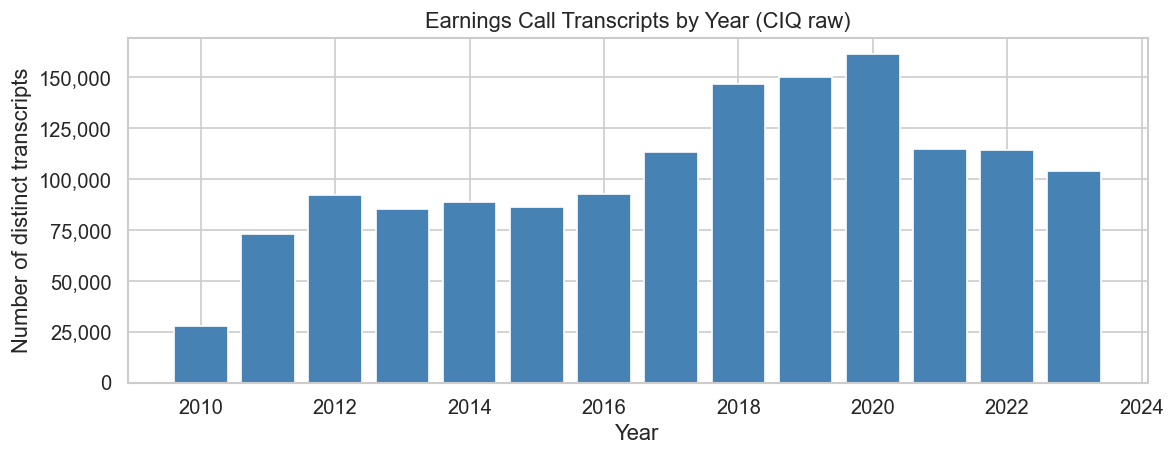

Plot saved to: /Users/tiantian/Downloads/CU Material/S3/5293/Project/LLM Project/src/notebooks/nb01_transcripts_by_year.png

Notebook 01 complete.  Raw parquets in /Users/tiantian/Downloads/CU Material/S3/5293/Project/LLM Project/Data  →  proceed to 02_spacy_baseline.ipynb.


In [34]:
# Save the summary table next to the notebook
output_path = NOTEBOOK_DIR / 'nb01_summary_stats.csv'
stats_df.to_csv(output_path)
print(f"Summary statistics saved to: {output_path}")

# Quick "transcripts per year" plot (one row per *transcript*, not per component)
if CIQ_PARQUET.exists():
    t_meta = pd.read_parquet(CIQ_PARQUET, columns=['transcriptid', 'call_date'])
    t_meta = t_meta.drop_duplicates('transcriptid')
    t_meta['year'] = pd.to_datetime(t_meta['call_date'], errors='coerce').dt.year
    by_year = t_meta.dropna(subset=['year']).groupby('year').size().sort_index()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(by_year.index.astype(int), by_year.values, color='steelblue')
    ax.set_title('Earnings Call Transcripts by Year (CIQ raw)')
    ax.set_xlabel('Year')
    ax.set_ylabel('Number of distinct transcripts')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.tight_layout()
    plot_path = NOTEBOOK_DIR / 'nb01_transcripts_by_year.png'
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Plot saved to: {plot_path}")

print(f"\nNotebook 01 complete.  Raw parquets in {RAW_DIR}  →  proceed to 02_spacy_baseline.ipynb.")